# Bandarban star-image RAW analysis

This notebook inventories the Sony ARW frames, makes neutral quicklooks, plate-solves them, and measures robust RAW-background diagnostics. It also derives **provisional Gaia-G-like** sky surface-brightness estimates; these are exploratory values with incomplete systematic-error accounting, not formal SQM measurements or Bortle classifications.

Scientific guardrails:

- Compare raw sensor values only after subtracting the camera black level.
- Treat frames as directly comparable only when exposure, aperture, ISO, focal length, and lens match.
- Stars, the Milky Way, clouds, airglow, terrain, vignetting, and light domes all affect these summaries.
- Site labels and plate-solved pointing are included; a defensible site result still needs Moon geometry, matched sky regions, repeated exposures, calibration frames, and fuller uncertainty propagation.

In [1]:
from pathlib import Path
from fractions import Fraction
import warnings

import exifread
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rawpy

pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'stars').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the project root containing stars/')

ROOT = find_project_root()
STAR_DIR = ROOT / 'stars'
FILES = sorted(STAR_DIR.glob('*.ARW'))
assert FILES, f'No ARW files found in {STAR_DIR}'
print(f'Project: {ROOT}')
print(f'Found {len(FILES)} ARW files')

Project: /Users/shahal-mac/Desktop/code/website
Found 7 ARW files


## 1. Metadata inventory

The filename prefixes supplied with the field log assign each frame to one of two sites. Coordinates below use the exact place-pin coordinates embedded in the supplied Google Maps links. Camera timestamps are treated as Asia/Dhaka local time, but the interleaved `k`/`sp` chronology should be verified before any time-sensitive conclusion.

In [2]:
SITE_CONFIG = {
    'K': {
        'site': 'K — Lala New Guest House / Keokradong area',
        'latitude_deg': 21.95193, 'longitude_deg': 92.5143994,
    },
    'SP': {
        'site': 'SP — Ala Mi Tlyang La Resort area',
        'latitude_deg': 21.9432147, 'longitude_deg': 92.5380896,
    },
}

def frame_site_code(filename):
    lower = filename.lower()
    if lower.startswith('sp'):
        return 'SP'
    if lower.startswith('k'):
        return 'K'
    raise ValueError(f'Unrecognized site prefix: {filename}')

FRAME_NOTES = {}
for path in FILES:
    site_code = frame_site_code(path.name)
    FRAME_NOTES[path.name] = {'site_code': site_code, **SITE_CONFIG[site_code]}
FRAME_NOTES.get('k.ARW', {}).update(
    {'subject': 'Andromeda field (confirmed by plate solution)'})

def tag_text(tags, name, default=None):
    value = tags.get(name)
    return str(value) if value is not None else default

def tag_number(tags, name):
    value = tag_text(tags, name)
    if value is None:
        return np.nan
    try:
        return float(Fraction(value))
    except (ValueError, ZeroDivisionError):
        return np.nan

def read_metadata(path):
    with path.open('rb') as stream:
        tags = exifread.process_file(stream, details=False)
    with rawpy.imread(str(path)) as raw:
        row = {
            'file': path.name,
            'captured': tag_text(tags, 'EXIF DateTimeOriginal'),
            'camera': tag_text(tags, 'Image Model'),
            'lens': tag_text(tags, 'EXIF LensModel'),
            'exposure_s': tag_number(tags, 'EXIF ExposureTime'),
            'f_number': tag_number(tags, 'EXIF FNumber'),
            'iso': tag_number(tags, 'EXIF ISOSpeedRatings'),
            'focal_length_mm': tag_number(tags, 'EXIF FocalLength'),
            'orientation': tag_text(tags, 'Image Orientation'),
            'raw_height': raw.raw_image_visible.shape[0],
            'raw_width': raw.raw_image_visible.shape[1],
            'black_levels': tuple(raw.black_level_per_channel),
            'white_level': raw.white_level,
        }
    row.update(FRAME_NOTES.get(path.name, {}))
    row.setdefault('site_code', None)
    row.setdefault('site', None)
    row.setdefault('latitude_deg', np.nan)
    row.setdefault('longitude_deg', np.nan)
    row.setdefault('subject', None)
    return row

metadata = pd.DataFrame(read_metadata(path) for path in FILES)
metadata['captured'] = pd.to_datetime(metadata['captured'], format='%Y:%m:%d %H:%M:%S')
metadata

,file,captured,camera,lens,exposure_s,f_number,iso,focal_length_mm,orientation,raw_height,raw_width,black_levels,white_level,site_code,site,latitude_deg,longitude_deg,subject
0,k.ARW,2026-09-14 21:24:24,ILCE-6400,56mm F1.4 DC DN | Contemporary 018,4.0,1.4,6400.0,56.0,Horizontal (normal),4024,6024,"(512, 512, 512, 512)",16380,K,K — Lala New Guest House / Keokradong area,21.951930,92.514399,Andromeda field (confirmed by plate solution)
1,k2.ARW,2026-09-14 20:59:22,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,3200.0,16.0,Rotated 90 CCW,4024,6024,"(512, 512, 512, 512)",16380,K,K — Lala New Guest House / Keokradong area,21.951930,92.514399,NaN
2,k3.ARW,2026-09-14 18:30:55,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,2500.0,16.0,Rotated 90 CCW,4024,6024,"(512, 512, 512, 512)",16380,K,K — Lala New Guest House / Keokradong area,21.951930,92.514399,NaN
3,sp 2.ARW,2026-09-14 21:12:29,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,3200.0,16.0,Horizontal (normal),4024,6024,"(512, 512, 512, 512)",16380,SP,SP — Ala Mi Tlyang La Resort area,21.943215,92.538090,NaN
4,sp.ARW,2026-09-14 21:11:14,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,3200.0,16.0,Horizontal (normal),4024,6024,"(512, 512, 512, 512)",16380,SP,SP — Ala Mi Tlyang La Resort area,21.943215,92.538090,NaN
5,sp3.ARW,2026-09-13 21:33:21,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,2000.0,16.0,Horizontal (normal),4024,6024,"(512, 512, 512, 512)",16380,SP,SP — Ala Mi Tlyang La Resort area,21.943215,92.538090,NaN
6,sp4.ARW,2026-09-13 21:44:33,ILCE-6400,16mm F1.4 DC DN | Contemporary 017,10.0,1.4,2000.0,16.0,Rotated 90 CCW,4024,6024,"(512, 512, 512, 512)",16380,SP,SP — Ala Mi Tlyang La Resort area,21.943215,92.538090,NaN


In [3]:
settings_cols = ['exposure_s', 'f_number', 'iso', 'focal_length_mm', 'lens']
settings_groups = (metadata.groupby(settings_cols, dropna=False)['file']
                   .agg(['count', lambda values: ', '.join(values)])
                   .rename(columns={'<lambda_0>': 'files'})
                   .sort_values('count', ascending=False))
settings_groups

count  \
exposure_s f_number iso    focal_length_mm lens                                        
10.0       1.4      3200.0 16.0            16mm F1.4 DC DN | Contemporary 017      3   
                    2000.0 16.0            16mm F1.4 DC DN | Contemporary 017      2   
4.0        1.4      6400.0 56.0            56mm F1.4 DC DN | Contemporary 018      1   
10.0       1.4      2500.0 16.0            16mm F1.4 DC DN | Contemporary 017      1   

                                                                                                  files  
exposure_s f_number iso    focal_length_mm lens                                                          
10.0       1.4      3200.0 16.0            16mm F1.4 DC DN | Contemporary 017  k2.ARW, sp 2.ARW, sp.ARW  
                    2000.0 16.0            16mm F1.4 DC DN | Contemporary 017          sp3.ARW, sp4.ARW  
4.0        1.4      6400.0 56.0            56mm F1.4 DC DN | Contemporary 018                     k.ARW  
10.0       1.4      2500.0 16.0            16mm F1.4 DC DN | Contemporary 017                    k3.ARW

## 2. Neutral quicklooks

These are display renderings only. Auto-brightening is disabled and every panel uses the same RAW-development parameters, but camera white balance and nonlinear display gamma are applied. Do not measure the rendered RGB panels.

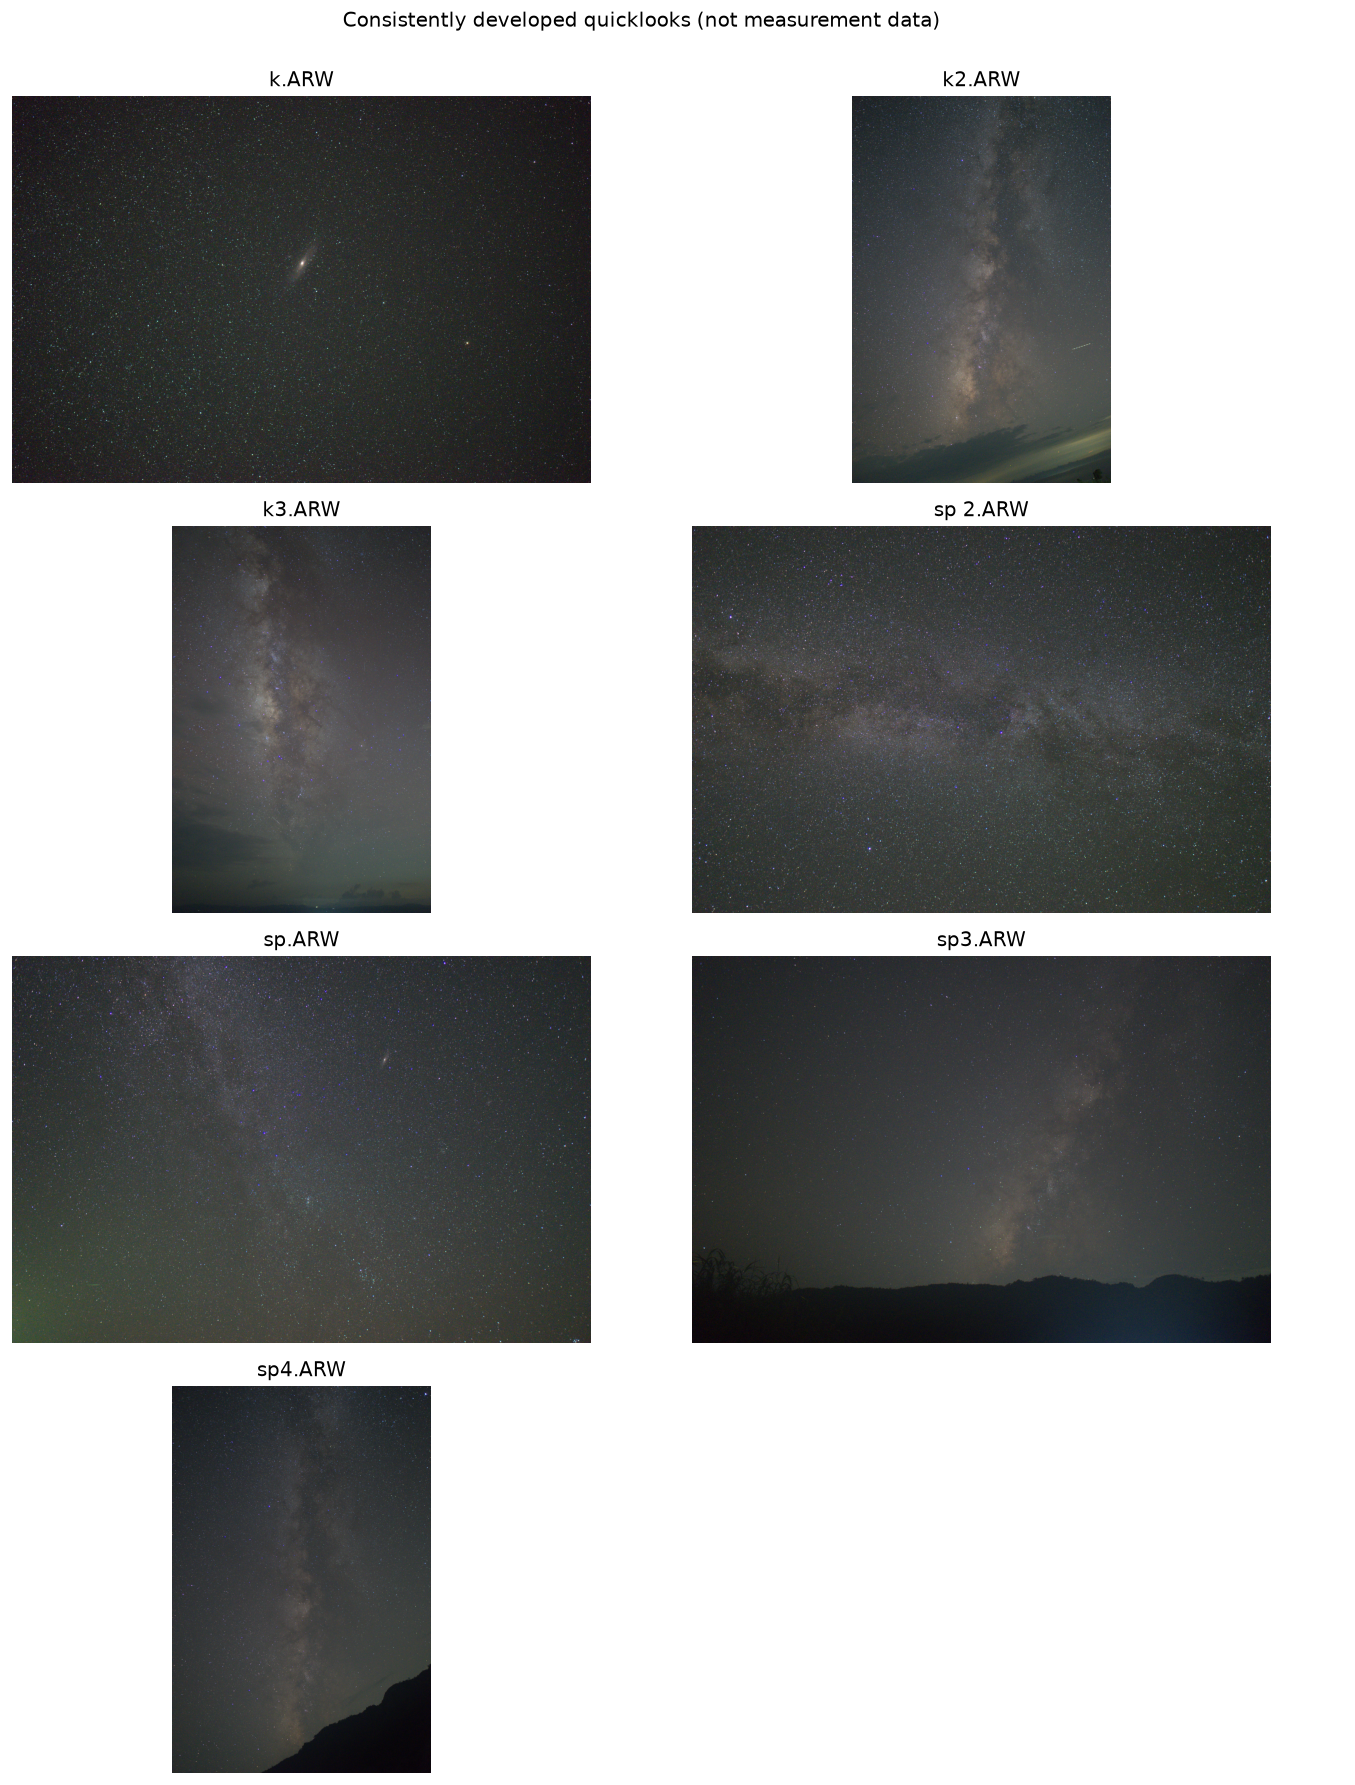

In [4]:
fig, axes = plt.subplots((len(FILES) + 1) // 2, 2, figsize=(12, 3.7 * ((len(FILES) + 1) // 2)))
axes = np.atleast_1d(axes).ravel()
for ax, path in zip(axes, FILES):
    with rawpy.imread(str(path)) as raw:
        rgb = raw.postprocess(
            use_camera_wb=True, half_size=True, output_bps=8,
            no_auto_bright=True, bright=3.0, gamma=(2.222, 4.5),
        )
    ax.imshow(rgb)
    ax.set_title(path.name)
    ax.axis('off')
for ax in axes[len(FILES):]:
    ax.axis('off')
fig.suptitle('Consistently developed quicklooks (not measurement data)', y=1.002)
fig.tight_layout()

## 3. Linear RAW diagnostics

The Sony sensor uses a Bayer mosaic. Statistics are calculated separately for R, G1, B, and G2 after subtracting the per-channel black level. To reduce the influence of borders, terrain, and strong lens falloff, the summary uses the central 60% of the sensor. A robust dispersion estimate is reported as `1.4826 × MAD`. The sky and Milky Way remain mixed in this region, so these are frame diagnostics—not isolated sky-background measurements.

In [5]:
def central_crop(array, fraction=0.60):
    height, width = array.shape
    dh, dw = int(height * fraction / 2), int(width * fraction / 2)
    cy, cx = height // 2, width // 2
    return array[cy-dh:cy+dh, cx-dw:cx+dw]

def raw_plane_statistics(path, crop_fraction=0.60):
    rows = []
    with rawpy.imread(str(path)) as raw:
        mosaic = central_crop(raw.raw_image_visible, crop_fraction)
        colors = central_crop(raw.raw_colors_visible, crop_fraction)
        labels = bytes(raw.color_desc).decode(errors='replace').rstrip('\x00')
        green_number = 0
        for color_index, black in enumerate(raw.black_level_per_channel):
            samples = mosaic[colors == color_index].astype(np.float64) - black
            median = float(np.median(samples))
            mad_sigma = float(1.4826 * np.median(np.abs(samples - median)))
            label = labels[color_index]
            if label == 'G':
                green_number += 1
                label = f'G{green_number}'
            rows.append({
                'file': path.name, 'plane': label,
                'median_adu_above_black': median,
                'robust_sigma_adu': mad_sigma,
                'p05_adu_above_black': float(np.percentile(samples, 5)),
                'p95_adu_above_black': float(np.percentile(samples, 95)),
                'saturated_fraction': float(np.mean(samples + black >= raw.white_level)),
            })
    return rows

raw_stats = pd.DataFrame(row for path in FILES for row in raw_plane_statistics(path))
raw_stats

,file,plane,median_adu_above_black,robust_sigma_adu,p05_adu_above_black,p95_adu_above_black,saturated_fraction
0,k.ARW,R,96.0,77.0952,0.0,236.0,7.335920e-06
1,k.ARW,G1,260.0,106.7472,112.0,484.0,4.997595e-05
2,k.ARW,B,132.0,77.0952,24.0,284.0,2.384174e-05
3,k.ARW,G2,264.0,106.7472,112.0,488.0,5.089294e-05
4,k2.ARW,R,248.0,100.8168,116.0,468.0,1.283786e-05
5,k2.ARW,G1,608.0,189.7728,356.0,1028.0,3.667960e-05
6,k2.ARW,B,308.0,94.8864,172.0,512.0,1.742281e-05
7,k2.ARW,G2,608.0,183.8424,360.0,1028.0,2.613421e-05
8,k3.ARW,R,316.0,94.8864,176.0,500.0,1.329635e-05
9,k3.ARW,G1,652.0,160.1208,388.0,1004.0,4.034756e-05


In [6]:
green_stats = (raw_stats[raw_stats['plane'].str.startswith('G')]
               .groupby('file', as_index=False)
               .agg(green_median_adu=('median_adu_above_black', 'mean'),
                    green_robust_sigma_adu=('robust_sigma_adu', 'mean'),
                    saturated_fraction=('saturated_fraction', 'mean'))
               .merge(metadata[['file', 'captured', 'exposure_s', 'f_number', 'iso',
                                'focal_length_mm', 'site', 'subject']], on='file'))
green_stats['relative_signal_per_exposure'] = (
    green_stats['green_median_adu'] * green_stats['f_number']**2
    / (green_stats['exposure_s'] * green_stats['iso'])
)
green_stats.sort_values('captured')

,file,green_median_adu,green_robust_sigma_adu,saturated_fraction,captured,exposure_s,f_number,iso,focal_length_mm,site,subject,relative_signal_per_exposure
5,sp3.ARW,424.0,112.6776,0.000004,2026-09-13 21:33:21,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN,0.041552
6,sp4.ARW,400.0,94.8864,0.000014,2026-09-13 21:44:33,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN,0.039200
2,k3.ARW,652.0,160.1208,0.000041,2026-09-14 18:30:55,10.0,1.4,2500.0,16.0,K — Lala New Guest House / Keokradong area,NaN,0.051117
1,k2.ARW,608.0,186.8076,0.000031,2026-09-14 20:59:22,10.0,1.4,3200.0,16.0,K — Lala New Guest House / Keokradong area,NaN,0.037240
4,sp.ARW,444.0,112.6776,0.000031,2026-09-14 21:11:14,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN,0.027195
3,sp 2.ARW,448.0,130.4688,0.000065,2026-09-14 21:12:29,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN,0.027440
0,k.ARW,262.0,106.7472,0.000050,2026-09-14 21:24:24,4.0,1.4,6400.0,56.0,K — Lala New Guest House / Keokradong area,Andromeda field (confirmed by plate solution),0.020059


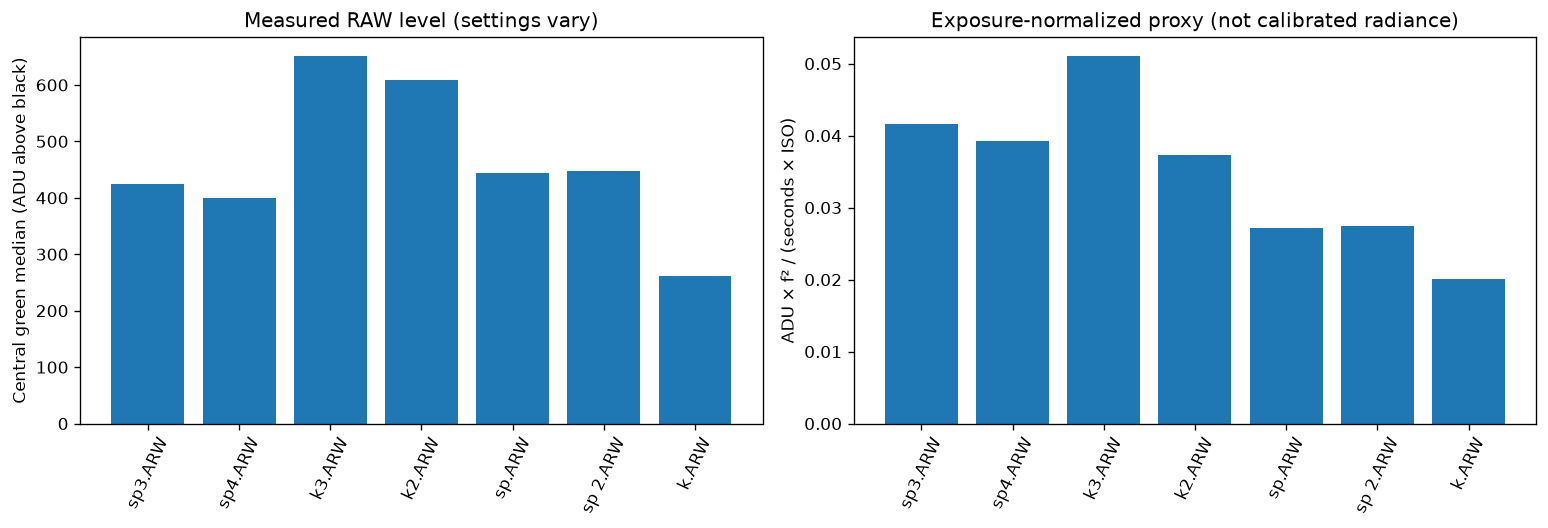

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_data = green_stats.sort_values('captured')
axes[0].bar(plot_data['file'], plot_data['green_median_adu'])
axes[0].set_ylabel('Central green median (ADU above black)')
axes[0].set_title('Measured RAW level (settings vary)')
axes[0].tick_params(axis='x', rotation=65)
axes[1].bar(plot_data['file'], plot_data['relative_signal_per_exposure'])
axes[1].set_ylabel('ADU × f² / (seconds × ISO)')
axes[1].set_title('Exposure-normalized proxy (not calibrated radiance)')
axes[1].tick_params(axis='x', rotation=65)
fig.tight_layout()

### Strict matched-settings subset

The largest directly comparable group is selected automatically below. Even within it, different pointings and cloud/Milky Way content can dominate the median. A lower median is therefore **not automatically a darker site**.

In [8]:
largest_key = metadata.groupby(settings_cols, dropna=False).size().idxmax()
matched_files = metadata.set_index(settings_cols).loc[[largest_key], 'file']
matched_files = [matched_files] if isinstance(matched_files, str) else matched_files.tolist()
matched = green_stats[green_stats['file'].isin(matched_files)].sort_values('captured').copy()
matched['relative_to_group_median'] = matched['green_median_adu'] / matched['green_median_adu'].median()
display(matched[['file', 'captured', 'green_median_adu', 'green_robust_sigma_adu',
                 'saturated_fraction', 'relative_to_group_median']])
print('Matched settings:', dict(zip(settings_cols, largest_key)))

,file,captured,green_median_adu,green_robust_sigma_adu,saturated_fraction,relative_to_group_median
1,k2.ARW,2026-09-14 20:59:22,608.0,186.8076,0.000031,1.357143
4,sp.ARW,2026-09-14 21:11:14,444.0,112.6776,0.000031,0.991071
3,sp 2.ARW,2026-09-14 21:12:29,448.0,130.4688,0.000065,1.000000


Matched settings: {'exposure_s': np.float64(10.0), 'f_number': np.float64(1.4), 'iso': np.float64(3200.0), 'focal_length_mm': np.float64(16.0), 'lens': '16mm F1.4 DC DN | Contemporary 017'}


## 4. Spatial background structure

These coarse maps use the average of the two black-subtracted green planes. Each tile is a median, which suppresses many stars but not the dense Milky Way or broad clouds. Maps are independently color-scaled between their 5th and 95th percentiles, so compare structure—not color brightness—between panels.

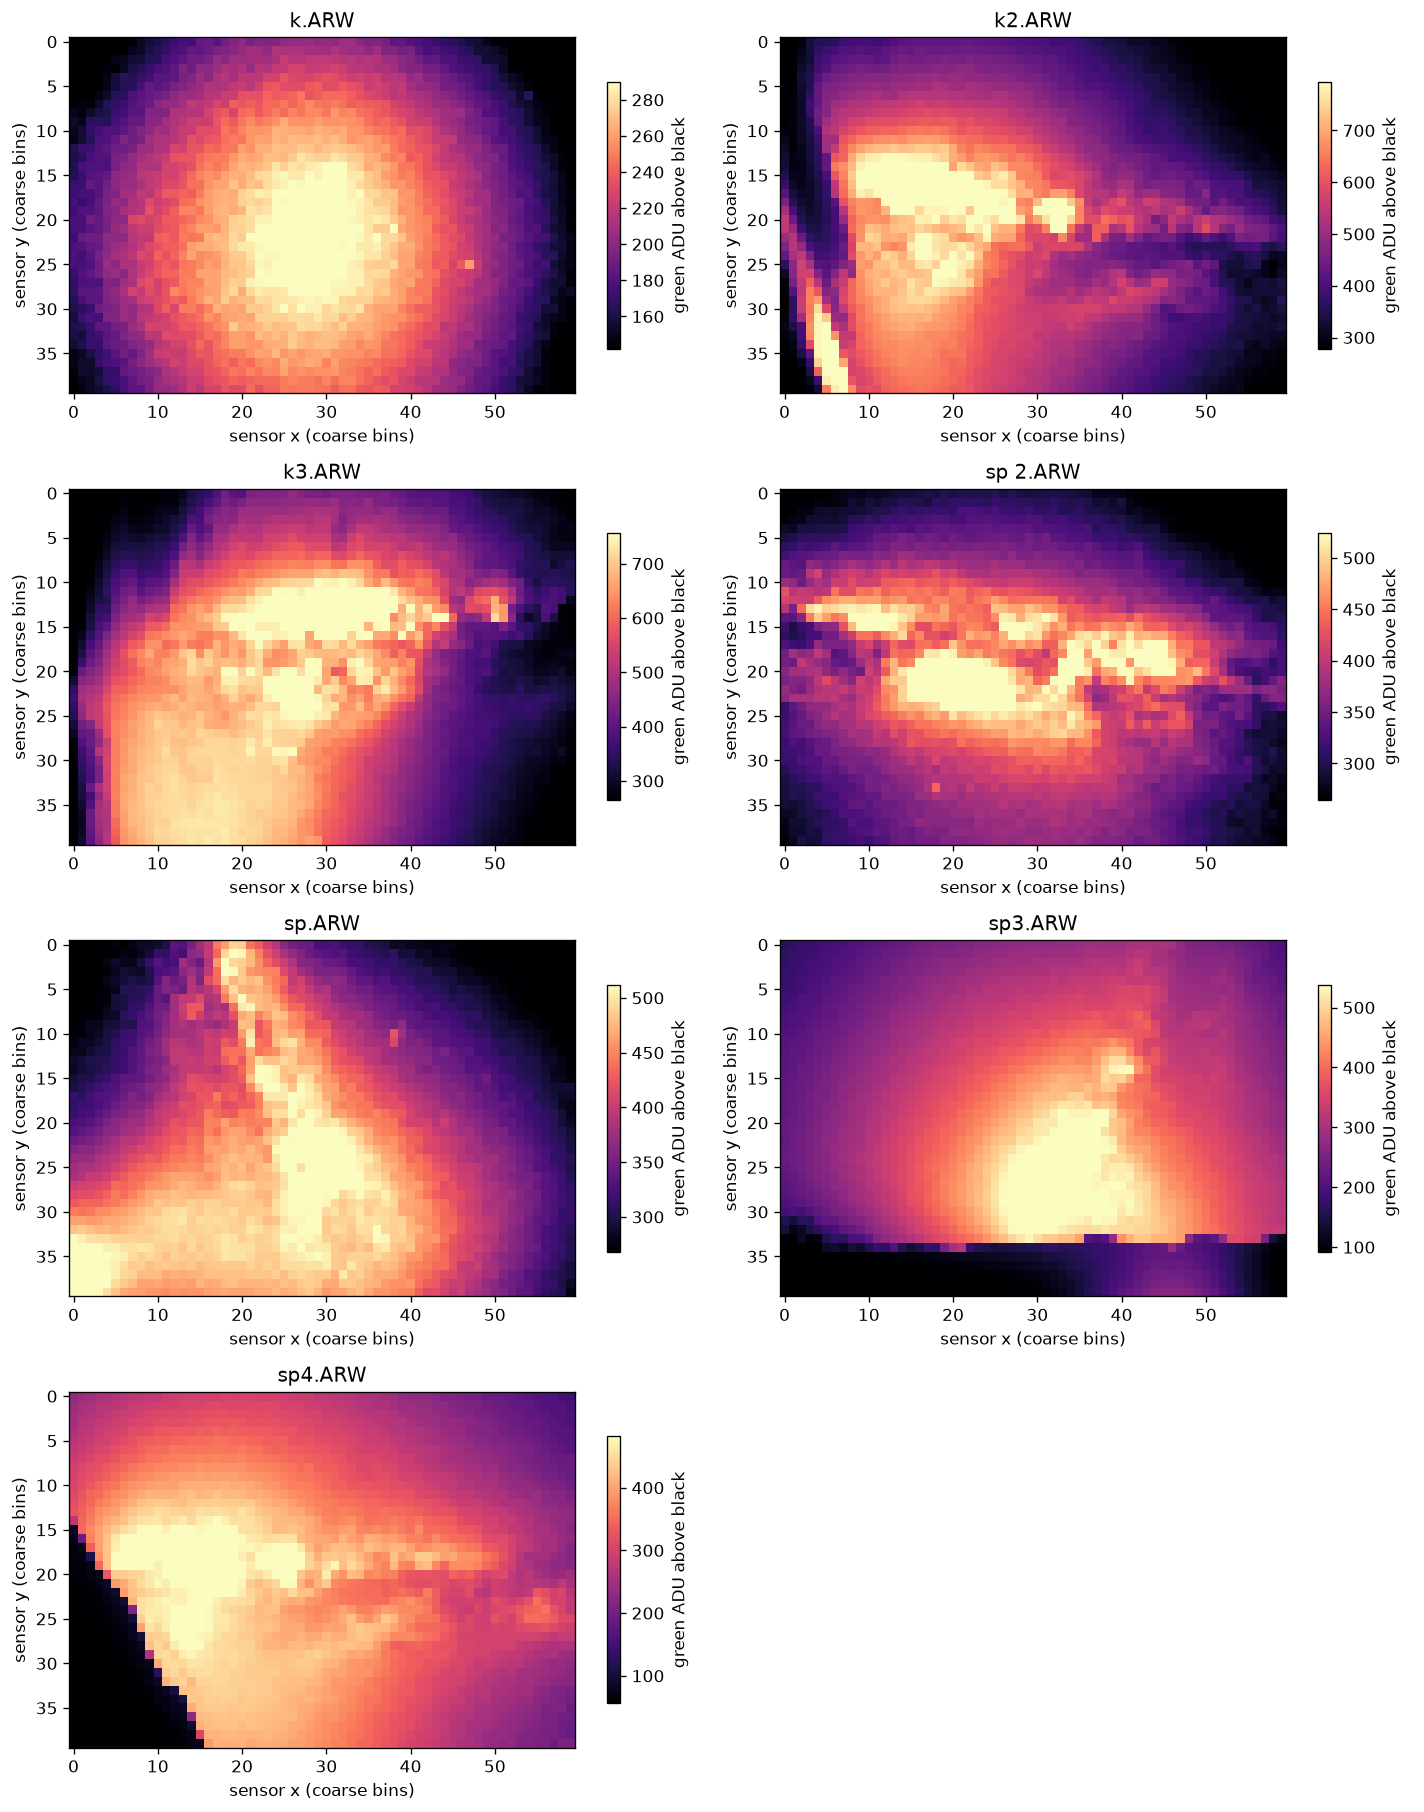

In [9]:
def green_background_map(path, rows=40, cols=60):
    with rawpy.imread(str(path)) as raw:
        mosaic = raw.raw_image_visible.astype(np.float32)
        colors = raw.raw_colors_visible
        green_indices = [i for i, label in enumerate(bytes(raw.color_desc).decode(errors='replace').rstrip('\x00')) if label == 'G']
        planes = []
        for index in green_indices:
            ys, xs = np.where(raw.raw_pattern == index)
            plane = mosaic[ys[0]::2, xs[0]::2] - raw.black_level_per_channel[index]
            planes.append(plane)
        green = np.mean(planes, axis=0)
    h = (green.shape[0] // rows) * rows
    w = (green.shape[1] // cols) * cols
    return np.median(green[:h, :w].reshape(rows, h//rows, cols, w//cols), axis=(1, 3))

fig, axes = plt.subplots((len(FILES) + 1) // 2, 2, figsize=(12, 3.8 * ((len(FILES) + 1) // 2)))
axes = np.atleast_1d(axes).ravel()
for ax, path in zip(axes, FILES):
    background = green_background_map(path)
    lo, hi = np.percentile(background, [5, 95])
    image = ax.imshow(background, origin='upper', cmap='magma', vmin=lo, vmax=hi, aspect='auto')
    ax.set_title(path.name)
    ax.set_xlabel('sensor x (coarse bins)')
    ax.set_ylabel('sensor y (coarse bins)')
    fig.colorbar(image, ax=ax, shrink=0.75, label='green ADU above black')
for ax in axes[len(FILES):]:
    ax.axis('off')
fig.tight_layout()

## 5. Star-resistant tile-background comparison

A single full-frame median can hide gradients and mix terrain with sky. This stage uses only the central 60% of the sensor, divides it into equal 50 × 50-pixel tiles on the half-resolution green plane, and takes the median within each tile. The tile median strongly limits the influence of ordinary stars and isolated hot pixels.

`low_sky_proxy_adu` is the 20th percentile of those tile medians. It samples the darker part of the central field without selecting a single exceptionally dark tile. It remains sensitive to vignetting, dust, real sky structure, and pointing, so it is a comparative diagnostic—not calibrated sky brightness.

In [10]:
def central_green_tile_medians(path, central_fraction=0.60, tile_size=50):
    with rawpy.imread(str(path)) as raw:
        mosaic = raw.raw_image_visible.astype(np.float32)
        labels = bytes(raw.color_desc).decode(errors='replace').rstrip('\x00')
        green_indices = [index for index, label in enumerate(labels) if label == 'G']
        planes = []
        for index in green_indices:
            ys, xs = np.where(raw.raw_pattern == index)
            planes.append(
                mosaic[ys[0]::2, xs[0]::2] - raw.black_level_per_channel[index]
            )
        green = np.mean(planes, axis=0)

    height, width = green.shape
    crop_h = int(height * central_fraction)
    crop_w = int(width * central_fraction)
    y0 = (height - crop_h) // 2
    x0 = (width - crop_w) // 2
    central = green[y0:y0+crop_h, x0:x0+crop_w]
    usable_h = (central.shape[0] // tile_size) * tile_size
    usable_w = (central.shape[1] // tile_size) * tile_size
    central = central[:usable_h, :usable_w]
    tiles = central.reshape(usable_h // tile_size, tile_size,
                            usable_w // tile_size, tile_size)
    return np.median(tiles, axis=(1, 3))

tile_maps = {path.name: central_green_tile_medians(path) for path in FILES}
tile_rows = []
for filename, values in tile_maps.items():
    p10, p20, p50, p80, p90 = np.percentile(values, [10, 20, 50, 80, 90])
    tile_rows.append({
        'file': filename,
        'low_sky_proxy_adu': p20,
        'tile_median_adu': p50,
        'tile_p10_adu': p10,
        'tile_p90_adu': p90,
        'tile_p80_minus_p20_adu': p80 - p20,
        'unevenness_fraction': (p80 - p20) / p50 if p50 > 0 else np.nan,
    })
tile_metrics = (pd.DataFrame(tile_rows)
                .merge(metadata[['file', 'captured', 'exposure_s', 'f_number', 'iso',
                                 'focal_length_mm', 'site', 'subject']], on='file'))
tile_metrics.sort_values('captured')

,file,low_sky_proxy_adu,tile_median_adu,tile_p10_adu,tile_p90_adu,tile_p80_minus_p20_adu,unevenness_fraction,captured,exposure_s,f_number,iso,focal_length_mm,site,subject
5,sp3.ARW,352.0,418.0,328.0,553.4,164.0,0.392344,2026-09-13 21:33:21,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
6,sp4.ARW,342.0,400.0,316.0,485.4,110.0,0.275000,2026-09-13 21:44:33,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
2,k3.ARW,552.0,668.0,458.0,789.4,180.0,0.269461,2026-09-14 18:30:55,10.0,1.4,2500.0,16.0,K — Lala New Guest House / Keokradong area,NaN
1,k2.ARW,488.0,594.5,444.0,806.0,252.0,0.423886,2026-09-14 20:59:22,10.0,1.4,3200.0,16.0,K — Lala New Guest House / Keokradong area,NaN
4,sp.ARW,395.2,448.0,372.0,510.0,96.8,0.216071,2026-09-14 21:11:14,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
3,sp 2.ARW,400.0,444.0,378.3,540.0,100.0,0.225225,2026-09-14 21:12:29,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
0,k.ARW,238.0,262.0,226.0,294.0,48.0,0.183206,2026-09-14 21:24:24,4.0,1.4,6400.0,56.0,K — Lala New Guest House / Keokradong area,Andromeda field (confirmed by plate solution)


,file,captured,low_sky_proxy_adu,tile_median_adu,tile_p80_minus_p20_adu,unevenness_fraction,low_sky_relative_to_group_median
1,k2.ARW,2026-09-14 20:59:22,488.0,594.5,252.0,0.423886,1.220
4,sp.ARW,2026-09-14 21:11:14,395.2,448.0,96.8,0.216071,0.988
3,sp 2.ARW,2026-09-14 21:12:29,400.0,444.0,100.0,0.225225,1.000


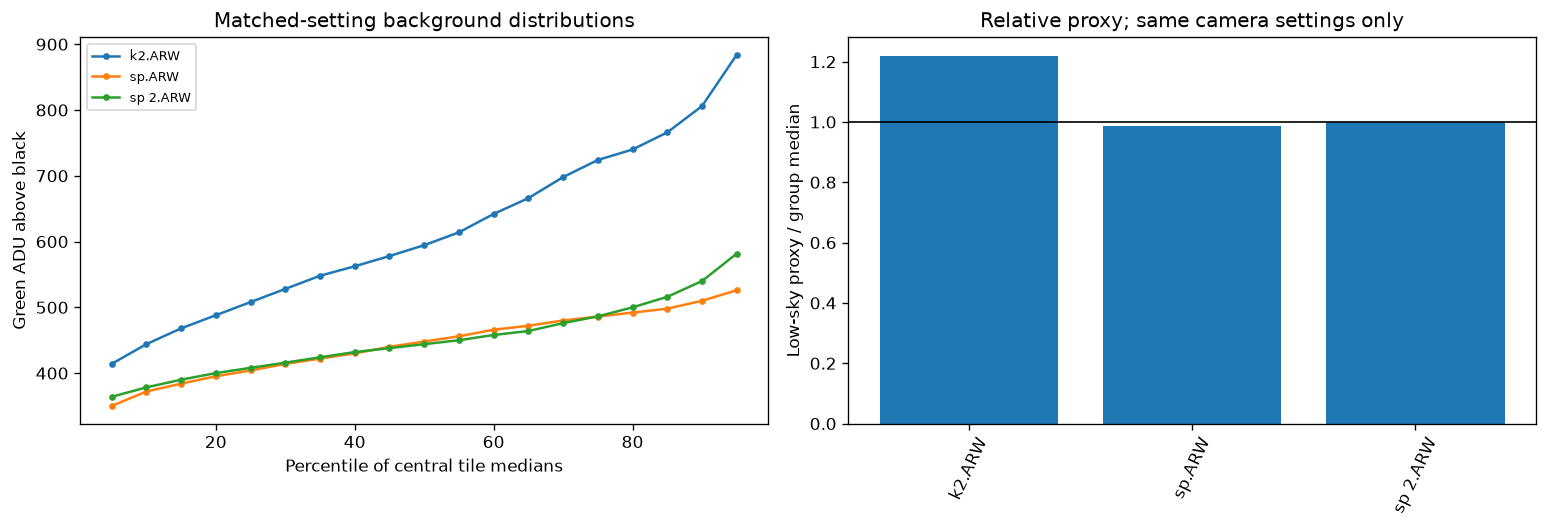

In [11]:
matched_tiles = (tile_metrics[tile_metrics['file'].isin(matched_files)]
                 .sort_values('captured').copy())
reference = matched_tiles['low_sky_proxy_adu'].median()
matched_tiles['low_sky_relative_to_group_median'] = matched_tiles['low_sky_proxy_adu'] / reference
display(matched_tiles[['file', 'captured', 'low_sky_proxy_adu', 'tile_median_adu',
                       'tile_p80_minus_p20_adu', 'unevenness_fraction',
                       'low_sky_relative_to_group_median']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for filename in matched_tiles['file']:
    axes[0].plot(np.arange(5, 100, 5),
                 np.percentile(tile_maps[filename], np.arange(5, 100, 5)),
                 marker='.', label=filename)
axes[0].set_xlabel('Percentile of central tile medians')
axes[0].set_ylabel('Green ADU above black')
axes[0].set_title('Matched-setting background distributions')
axes[0].legend(fontsize=8)

axes[1].bar(matched_tiles['file'], matched_tiles['low_sky_relative_to_group_median'])
axes[1].axhline(1, color='black', linewidth=1)
axes[1].set_ylabel('Low-sky proxy / group median')
axes[1].set_title('Relative proxy; same camera settings only')
axes[1].tick_params(axis='x', rotation=65)
fig.tight_layout()

In [12]:
# The two SP frames with matching settings bracket 75 seconds; the former middle frame
# is no longer present after the rename, so this is now a two-frame check.
sequence_names = ['sp.ARW', 'sp 2.ARW']
sequence = tile_metrics[tile_metrics['file'].isin(sequence_names)].sort_values('captured').copy()
if len(sequence) >= 2:
    sequence['seconds_from_first'] = (sequence['captured'] - sequence['captured'].iloc[0]).dt.total_seconds()
    spread = 100 * (sequence['low_sky_proxy_adu'].max() - sequence['low_sky_proxy_adu'].min()) / sequence['low_sky_proxy_adu'].median()
    display(sequence[['file', 'seconds_from_first', 'low_sky_proxy_adu',
                      'tile_median_adu', 'unevenness_fraction']])
    print(f'Peak-to-peak low-sky-proxy spread across this short sequence: {spread:.1f}%')
else:
    print('The expected two-frame SP sequence is incomplete.')

,file,seconds_from_first,low_sky_proxy_adu,tile_median_adu,unevenness_fraction
4,sp.ARW,0.0,395.2,448.0,0.216071
3,sp 2.ARW,75.0,400.0,444.0,0.225225


Peak-to-peak low-sky-proxy spread across this short sequence: 1.2%


## 6. Verified sky-only masks

The normalized polygons below were selected from sensor-native previews. They exclude visible mountains, vegetation, and the strongest horizon/cloud edge; fully sky-filled frames retain an 8% border margin to reduce edge-vignetting effects. The overlays are part of the result and should be reviewed whenever a polygon is edited.

These polygons isolate **sky**, but not necessarily identical sky. Diffuse Milky Way structure, airglow, thin cloud, and different elevations or azimuths may remain. Tile medians suppress ordinary stars; the 20th percentile of accepted tile medians reduces the effect of bright diffuse structure without pretending it is a calibrated background.

In [13]:
from matplotlib.path import Path as MatplotlibPath
from matplotlib.patches import Polygon as PolygonPatch

# Vertices are (x_fraction, y_fraction) in the unrotated sensor plane.
SKY_POLYGONS = {
    'sp3.ARW': [(0.08, 0.08), (0.92, 0.08), (0.92, 0.68), (0.08, 0.68)],
    'sp4.ARW': [(0.30, 0.08), (0.92, 0.08), (0.92, 0.92), (0.30, 0.92)],
    'k3.ARW': [(0.18, 0.08), (0.92, 0.08), (0.92, 0.92), (0.18, 0.92)],
    'k2.ARW': [(0.32, 0.08), (0.92, 0.08), (0.92, 0.92), (0.32, 0.92)],
    'sp.ARW': [(0.08, 0.08), (0.92, 0.08), (0.92, 0.92), (0.08, 0.92)],
    'sp 2.ARW': [(0.08, 0.08), (0.92, 0.08), (0.92, 0.92), (0.08, 0.92)],
    'k.ARW': [(0.08, 0.08), (0.92, 0.08), (0.92, 0.92), (0.08, 0.92)],
}
assert set(SKY_POLYGONS) == {path.name for path in FILES}

def black_subtracted_green(path):
    with rawpy.imread(str(path)) as raw:
        mosaic = raw.raw_image_visible.astype(np.float32)
        labels = bytes(raw.color_desc).decode(errors='replace').rstrip('\x00')
        planes = []
        for index, label in enumerate(labels):
            if label == 'G':
                ys, xs = np.where(raw.raw_pattern == index)
                planes.append(mosaic[ys[0]::2, xs[0]::2] - raw.black_level_per_channel[index])
    return np.mean(planes, axis=0)

def polygon_mask(shape, normalized_vertices):
    height, width = shape
    yy, xx = np.mgrid[0:height, 0:width]
    points = np.column_stack((xx.ravel() / (width - 1), yy.ravel() / (height - 1)))
    return MatplotlibPath(normalized_vertices).contains_points(points).reshape(shape)

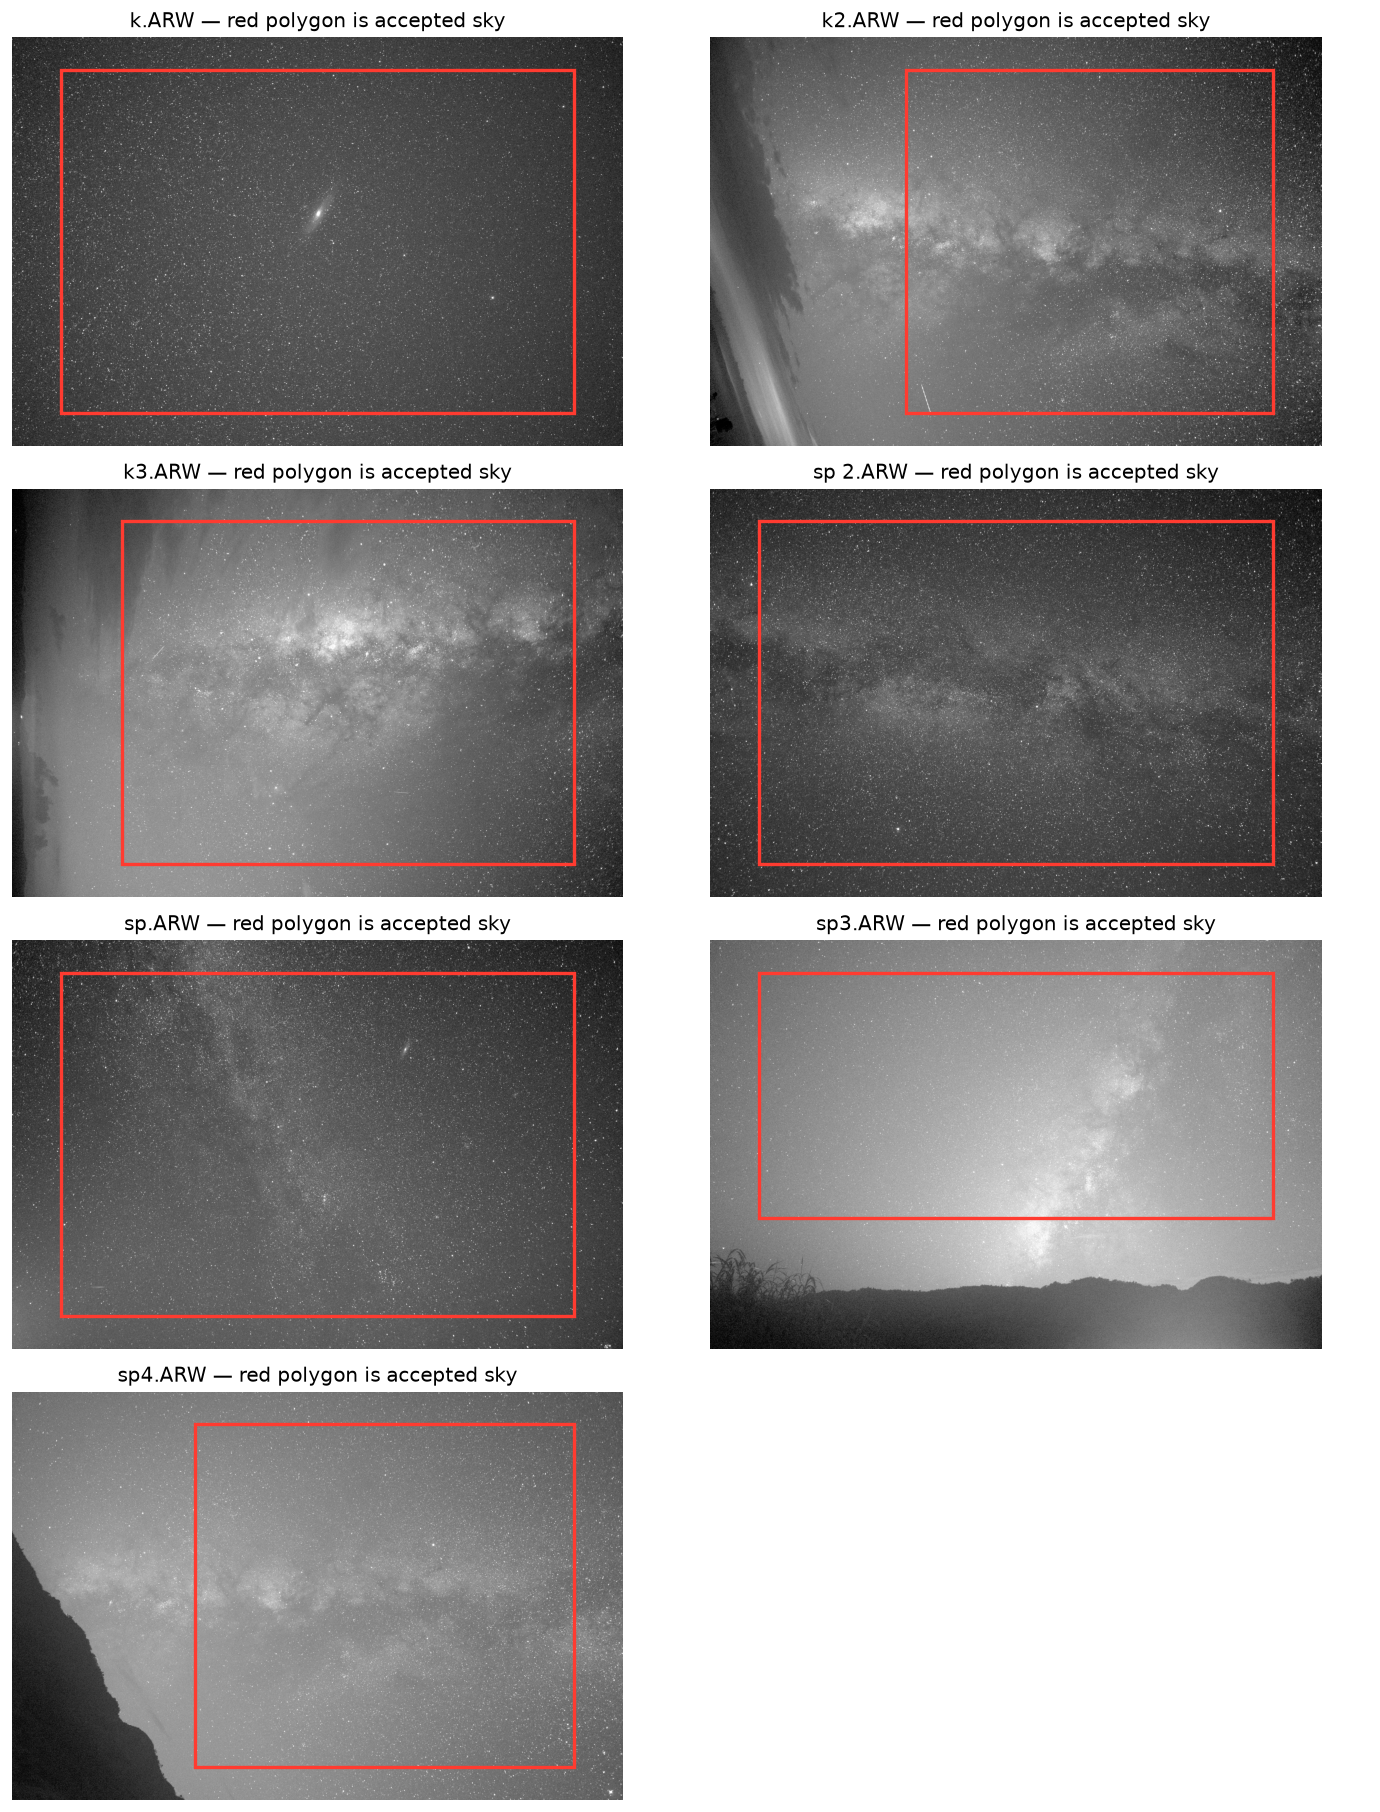

In [14]:
fig, axes = plt.subplots((len(FILES) + 1) // 2, 2, figsize=(12, 3.8 * ((len(FILES) + 1) // 2)))
axes = np.atleast_1d(axes).ravel()
green_planes = {}
for ax, path in zip(axes, FILES):
    green = black_subtracted_green(path)
    green_planes[path.name] = green
    lo, hi = np.percentile(green, [1, 99.7])
    display_green = np.sqrt(np.clip((green - lo) / (hi - lo), 0, 1))
    ax.imshow(display_green, cmap='gray', origin='upper')
    height, width = green.shape
    vertices = np.asarray(SKY_POLYGONS[path.name]) * np.array([width - 1, height - 1])
    ax.add_patch(PolygonPatch(vertices, closed=True, fill=False, edgecolor='#ff3b30', linewidth=2))
    ax.set_title(path.name + ' — red polygon is accepted sky')
    ax.axis('off')
for ax in axes[len(FILES):]:
    ax.axis('off')
fig.tight_layout()

In [15]:
def masked_tile_medians(values, mask, tile_size=50, minimum_mask_fraction=0.98):
    height = (values.shape[0] // tile_size) * tile_size
    width = (values.shape[1] // tile_size) * tile_size
    value_tiles = values[:height, :width].reshape(
        height // tile_size, tile_size, width // tile_size, tile_size)
    mask_tiles = mask[:height, :width].reshape(
        height // tile_size, tile_size, width // tile_size, tile_size)
    medians = np.median(value_tiles, axis=(1, 3))
    accepted = np.mean(mask_tiles, axis=(1, 3)) >= minimum_mask_fraction
    return medians[accepted]

sky_tile_values = {}
sky_rows = []
for path in FILES:
    green = green_planes[path.name]
    mask = polygon_mask(green.shape, SKY_POLYGONS[path.name])
    values = masked_tile_medians(green, mask)
    sky_tile_values[path.name] = values
    p10, p20, p50, p80, p90 = np.percentile(values, [10, 20, 50, 80, 90])
    sky_rows.append({
        'file': path.name, 'accepted_tiles': len(values),
        'sky_low_proxy_adu': p20, 'sky_median_adu': p50,
        'sky_p10_adu': p10, 'sky_p90_adu': p90,
        'sky_p80_minus_p20_adu': p80 - p20,
        'sky_unevenness_fraction': (p80 - p20) / p50 if p50 > 0 else np.nan,
    })
sky_metrics = (pd.DataFrame(sky_rows)
               .merge(metadata[['file', 'captured', 'exposure_s', 'f_number', 'iso',
                                'focal_length_mm', 'site', 'subject']], on='file'))
sky_metrics.sort_values('captured')

,file,accepted_tiles,sky_low_proxy_adu,sky_median_adu,sky_p10_adu,sky_p90_adu,sky_p80_minus_p20_adu,sky_unevenness_fraction,captured,exposure_s,f_number,iso,focal_length_mm,site,subject
5,sp3.ARW,1150,298.0,354.0,274.0,498.0,142.0,0.401130,2026-09-13 21:33:21,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
6,sp4.ARW,1188,290.0,352.0,264.0,434.3,130.0,0.369318,2026-09-13 21:44:33,10.0,1.4,2000.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
2,k3.ARW,1452,418.4,610.0,360.0,743.8,295.6,0.484590,2026-09-14 18:30:55,10.0,1.4,2500.0,16.0,K — Lala New Guest House / Keokradong area,NaN
1,k2.ARW,1155,398.0,506.0,356.0,692.0,214.0,0.422925,2026-09-14 20:59:22,10.0,1.4,3200.0,16.0,K — Lala New Guest House / Keokradong area,NaN
4,sp.ARW,1650,354.0,426.0,326.0,500.0,134.0,0.314554,2026-09-14 21:11:14,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
3,sp 2.ARW,1650,348.0,399.0,326.9,508.0,116.0,0.290727,2026-09-14 21:12:29,10.0,1.4,3200.0,16.0,SP — Ala Mi Tlyang La Resort area,NaN
0,k.ARW,1650,204.0,240.0,187.9,286.0,68.0,0.283333,2026-09-14 21:24:24,4.0,1.4,6400.0,56.0,K — Lala New Guest House / Keokradong area,Andromeda field (confirmed by plate solution)


,file,captured,accepted_tiles,sky_low_proxy_adu,sky_median_adu,sky_unevenness_fraction,relative_to_matched_median
1,k2.ARW,2026-09-14 20:59:22,1155,398.0,506.0,0.422925,1.124294
4,sp.ARW,2026-09-14 21:11:14,1650,354.0,426.0,0.314554,1.000000
3,sp 2.ARW,2026-09-14 21:12:29,1650,348.0,399.0,0.290727,0.983051


Three-frame sky-only peak-to-peak spread: 1.7%


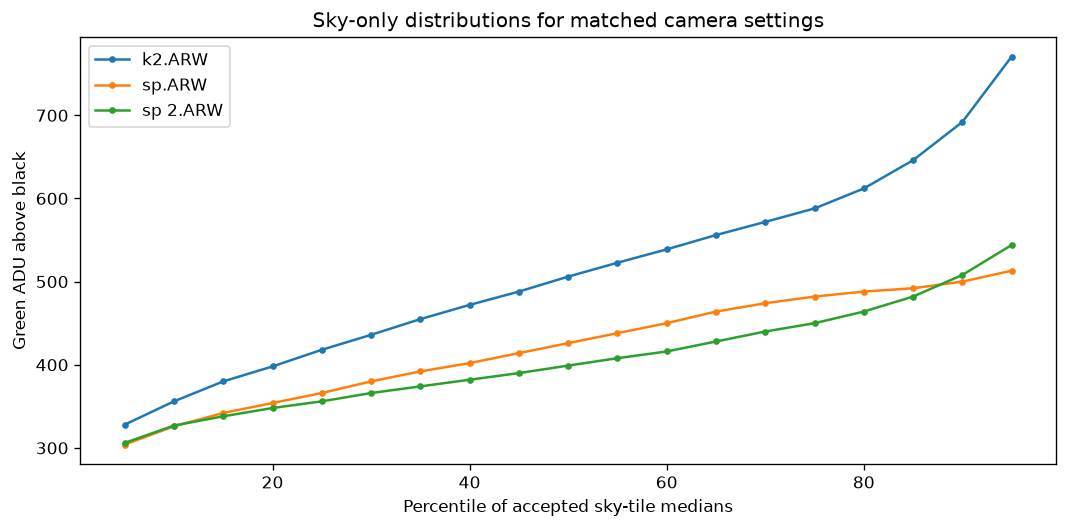

In [16]:
matched_sky = sky_metrics[sky_metrics['file'].isin(matched_files)].sort_values('captured').copy()
sky_reference = matched_sky['sky_low_proxy_adu'].median()
matched_sky['relative_to_matched_median'] = matched_sky['sky_low_proxy_adu'] / sky_reference
display(matched_sky[['file', 'captured', 'accepted_tiles', 'sky_low_proxy_adu',
                     'sky_median_adu', 'sky_unevenness_fraction',
                     'relative_to_matched_median']])

sequence_sky = matched_sky[matched_sky['file'].isin(sequence_names)].copy()
sequence_spread = 100 * (sequence_sky['sky_low_proxy_adu'].max() - sequence_sky['sky_low_proxy_adu'].min()) / sequence_sky['sky_low_proxy_adu'].median()
print(f'Three-frame sky-only peak-to-peak spread: {sequence_spread:.1f}%')

fig, ax = plt.subplots(figsize=(9, 4.5))
for filename in matched_sky['file']:
    ax.plot(np.arange(5, 100, 5),
            np.percentile(sky_tile_values[filename], np.arange(5, 100, 5)),
            marker='.', label=filename)
ax.set_xlabel('Percentile of accepted sky-tile medians')
ax.set_ylabel('Green ADU above black')
ax.set_title('Sky-only distributions for matched camera settings')
ax.legend()
fig.tight_layout()

## 7. Offline plate solving

Plate solving is performed locally with [Tetra3RS](https://github.com/ssmichael1/tetra3rs) and its bundled Gaia/Hipparcos bright-star catalog; no photograph is uploaded. A 10°–80° multiscale pattern database covers both lenses. The seven 16 mm pointings jointly fit one radial-distortion camera model. The single 56 mm frame receives a lower-parameter radial fit, whose residual is an internal fit rather than independent calibration. Python 3.10 or newer is required for this section.

In [17]:
import tetra3rs

PLATE_CACHE = ROOT / '.cache' / 'astrometry'
PLATE_CACHE.mkdir(parents=True, exist_ok=True)
PLATE_DB_PATH = PLATE_CACHE / 'tetra3-gaia-mag7-fov10-80-epoch2026.bin'

if PLATE_DB_PATH.exists():
    plate_db = tetra3rs.SolverDatabase.load_from_file(str(PLATE_DB_PATH))
    print('Loaded cached plate database:', PLATE_DB_PATH)
else:
    plate_db = tetra3rs.SolverDatabase.generate_from_gaia(
        max_fov_deg=80.0, min_fov_deg=10.0, star_max_magnitude=7.0,
        pattern_max_error=0.005, lattice_field_oversampling=50,
        patterns_per_lattice_field=30, verification_stars_per_fov=100,
        multiscale_step=1.4, epoch_proper_motion_year=2026.0,
    )
    plate_db.save_to_file(str(PLATE_DB_PATH))
    print('Generated and cached plate database:', PLATE_DB_PATH)

Loaded cached plate database: /Users/shahal-mac/Desktop/code/website/.cache/astrometry/tetra3-gaia-mag7-fov10-80-epoch2026.bin


In [18]:
def extract_plate_centroids(green):
    return tetra3rs.extract_centroids(
        green, sigma_threshold=20, min_pixels=2, max_pixels=200,
        max_centroids=350, local_bg_block_size=64,
        max_elongation=3, max_sharpness=1, border_margin=30,
    )

plate_extractions = {}
initial_plate_solutions = {}
for path in FILES:
    extraction = extract_plate_centroids(green_planes[path.name])
    plate_extractions[path.name] = extraction
    focal_length = float(metadata.loc[metadata['file'] == path.name, 'focal_length_mm'].iloc[0])
    fov_guess = 24.0 if focal_length > 30 else 73.0
    solution = plate_db.solve_from_centroids(
        extraction.centroids, fov_estimate_deg=fov_guess,
        image_width=extraction.image_width, image_height=extraction.image_height,
        fov_max_error_deg=4 if focal_length > 30 else 12,
        match_radius=0.03, match_threshold=1e-5,
        solve_timeout_ms=3000, max_patterns_checked=200_000,
    )
    if not solution:
        raise RuntimeError(f'Initial plate solve failed for {path.name}: {solution.status}')
    initial_plate_solutions[path.name] = solution
    print(path.name, solution)

k.ARW SolveResult: RA 12.1002°, Dec 41.6653°, Roll 71.50°, 72 matches, RMSE 97.09", prob 3.32e-77
k2.ARW SolveResult: RA 280.3895°, Dec -10.7821°, Roll -56.61°, 91 matches, RMSE 676.60", prob 1.83e-63
k3.ARW SolveResult: RA 262.7255°, Dec -28.0460°, Roll -62.95°, 86 matches, RMSE 825.08", prob 1.72e-60
sp 2.ARW SolveResult: RA 309.5720°, Dec 42.0666°, Roll -46.87°, 99 matches, RMSE 1232.61", prob 8.43e-46
sp.ARW SolveResult: RA 21.8547°, Dec 56.6766°, Roll 72.74°, 100 matches, RMSE 1144.74", prob 5.48e-72
sp3.ARW SolveResult: RA 284.8907°, Dec -23.1579°, Roll -129.14°, 56 matches, RMSE 156.47", prob 5.50e-67
sp4.ARW SolveResult: RA 284.7507°, Dec -1.5492°, Roll -62.84°, 75 matches, RMSE 450.76", prob 7.31e-74


In [19]:
wide_names = metadata.loc[metadata['focal_length_mm'] == 16, 'file'].tolist()
tele_names = metadata.loc[metadata['focal_length_mm'] == 56, 'file'].tolist()

wide_calibration = plate_db.calibrate_camera(
    [initial_plate_solutions[name] for name in wide_names],
    [plate_extractions[name].centroids for name in wide_names],
    image_width=3012, image_height=2012, model='radial',
    max_iterations=20, sigma_clip=3.0, convergence_threshold_px=0.001,
)
tele_calibration = plate_db.calibrate_camera(
    [initial_plate_solutions[name] for name in tele_names],
    [plate_extractions[name].centroids for name in tele_names],
    image_width=3012, image_height=2012, model='radial',
    max_iterations=20, sigma_clip=3.0, convergence_threshold_px=0.001,
)
print('16 mm calibration:', wide_calibration)
print('56 mm calibration:', tele_calibration)

final_plate_solutions = {}
for path in FILES:
    focal_length = float(metadata.loc[metadata['file'] == path.name, 'focal_length_mm'].iloc[0])
    camera_model = tele_calibration.camera_model if focal_length > 30 else wide_calibration.camera_model
    solution = plate_db.solve_from_centroids(
        plate_extractions[path.name].centroids, camera_model=camera_model,
        match_radius=0.010 if focal_length > 30 else 0.015,
        match_threshold=1e-6, solve_timeout_ms=3000,
        max_patterns_checked=200_000,
    )
    if not solution:
        raise RuntimeError(f'Distortion-aware solve failed for {path.name}: {solution.status}')
    final_plate_solutions[path.name] = solution

16 mm calibration: CalibrateResult(rmse=24.293->1.949 px, inliers=1563, outliers=402, iterations=116)
56 mm calibration: CalibrateResult(rmse=3.383->0.413 px, inliers=65, outliers=7, iterations=13)


In [20]:
def format_ra(ra_deg):
    total_seconds = (ra_deg % 360) / 15 * 3600
    hours = int(total_seconds // 3600)
    minutes = int((total_seconds % 3600) // 60)
    seconds = total_seconds % 60
    return f'{hours:02d}h {minutes:02d}m {seconds:04.1f}s'

def format_dec(dec_deg):
    sign = '+' if dec_deg >= 0 else '-'
    value = abs(dec_deg)
    degrees = int(value)
    minutes = int((value - degrees) * 60)
    seconds = (value - degrees - minutes / 60) * 3600
    return f'{sign}{degrees:02d}° {minutes:02d}′ {seconds:04.1f}″'

plate_rows = []
for path in FILES:
    solution = final_plate_solutions[path.name]
    plate_rows.append({
        'file': path.name, 'center_ra_deg': solution.ra_deg,
        'center_dec_deg': solution.dec_deg, 'center_ra_hms': format_ra(solution.ra_deg),
        'center_dec_dms': format_dec(solution.dec_deg), 'roll_deg': solution.roll_deg,
        'horizontal_fov_deg': solution.fov_deg, 'matched_stars': solution.num_matches,
        'internal_rmse_arcsec': solution.rmse_arcsec,
        'false_match_probability': solution.probability,
    })
plate_solutions = pd.DataFrame(plate_rows).merge(
    metadata[['file', 'captured', 'focal_length_mm', 'site', 'subject']], on='file')
plate_solutions.sort_values('captured')

,file,center_ra_deg,center_dec_deg,center_ra_hms,center_dec_dms,roll_deg,horizontal_fov_deg,matched_stars,internal_rmse_arcsec,false_match_probability,captured,focal_length_mm,site,subject
5,sp3.ARW,284.882121,-23.163598,18h 59m 31.7s,-23° 09′ 49.0″,-129.138572,71.113998,72,41.765867,6.195896e-126,2026-09-13 21:33:21,16.0,SP — Ala Mi Tlyang La Resort area,NaN
6,sp4.ARW,284.738415,-1.526154,18h 58m 57.2s,-01° 31′ 34.2″,-62.799450,71.036057,89,60.560028,9.628227e-180,2026-09-13 21:44:33,16.0,SP — Ala Mi Tlyang La Resort area,NaN
2,k3.ARW,262.678256,-28.076123,17h 30m 42.8s,-28° 04′ 34.0″,-62.995211,71.025841,88,68.921339,2.344401e-184,2026-09-14 18:30:55,16.0,K — Lala New Guest House / Keokradong area,NaN
1,k2.ARW,280.329528,-10.857896,18h 41m 19.1s,-10° 51′ 28.4″,-56.572641,71.038902,86,54.379075,9.212558e-166,2026-09-14 20:59:22,16.0,K — Lala New Guest House / Keokradong area,NaN
4,sp.ARW,21.904874,56.584984,01h 27m 37.2s,+56° 35′ 05.9″,72.774842,71.080185,86,63.275195,5.767150e-201,2026-09-14 21:11:14,16.0,SP — Ala Mi Tlyang La Resort area,NaN
3,sp 2.ARW,309.593218,41.994611,20h 38m 22.4s,+41° 59′ 40.6″,-46.824867,71.112770,91,123.651110,1.343992e-176,2026-09-14 21:12:29,16.0,SP — Ala Mi Tlyang La Resort area,NaN
0,k.ARW,12.094041,41.662754,00h 48m 22.6s,+41° 39′ 45.9″,71.521298,24.410875,79,12.069753,6.209192e-142,2026-09-14 21:24:24,56.0,K — Lala New Guest House / Keokradong area,Andromeda field (confirmed by plate solution)


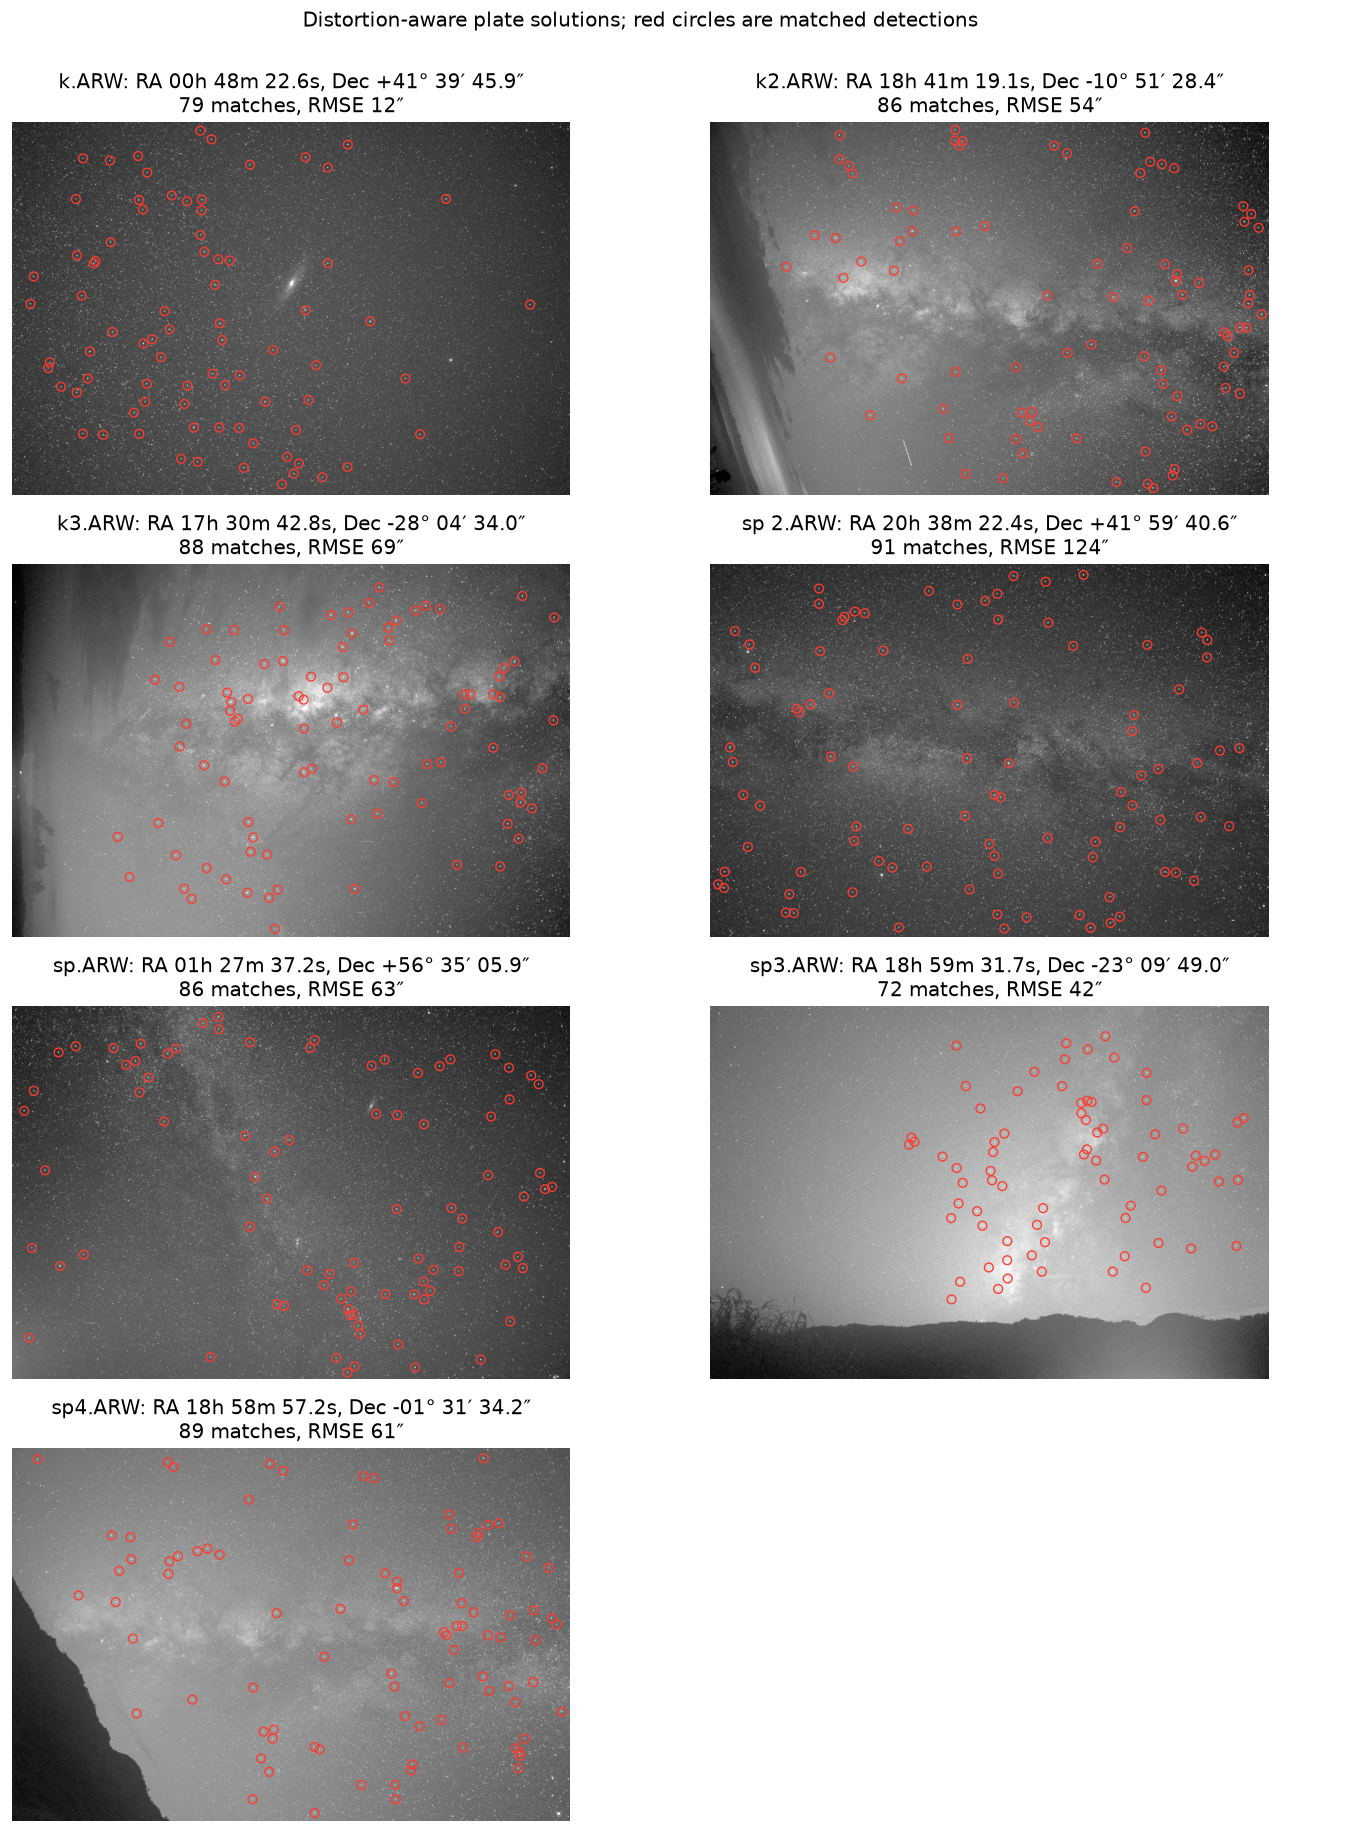

In [21]:
fig, axes = plt.subplots((len(FILES) + 1) // 2, 2, figsize=(12, 3.8 * ((len(FILES) + 1) // 2)))
axes = np.atleast_1d(axes).ravel()
for ax, path in zip(axes, FILES):
    green = green_planes[path.name]
    lo, hi = np.percentile(green, [1, 99.7])
    ax.imshow(np.sqrt(np.clip((green - lo) / (hi - lo), 0, 1)), cmap='gray', origin='upper')
    extraction = plate_extractions[path.name]
    solution = final_plate_solutions[path.name]
    matched = [extraction.centroids[int(index)] for index in solution.matched_centroids]
    xs = [star.x + extraction.image_width / 2 for star in matched]
    ys = [star.y + extraction.image_height / 2 for star in matched]
    ax.scatter(xs, ys, s=28, facecolors='none', edgecolors='#ff3b30', linewidths=0.8)
    ax.set_title(f'{path.name}: RA {format_ra(solution.ra_deg)}, Dec {format_dec(solution.dec_deg)}\n'
                 f'{solution.num_matches} matches, RMSE {solution.rmse_arcsec:.0f}″')
    ax.axis('off')
for ax in axes[len(FILES):]:
    ax.axis('off')
fig.suptitle('Distortion-aware plate solutions; red circles are matched detections', y=1.002)
fig.tight_layout()

## 8. Provisional Gaia-G photometric calibration

The bundled catalog stores Gaia `phot_g_mean_mag`. Fainter catalog stars are projected through each distortion-aware plate solution and matched to detected centroids. Aperture fluxes are measured on the linear, black-subtracted green RAW plane with a local sky annulus. Saturated stars, weak detections, large astrometric separations, duplicate matches, and robust zero-point outliers are rejected.

The resulting surface brightness is a **provisional Gaia-G-like estimate**, not a publication-ready standard-band measurement. Missing dark frames, flat fields, camera linearity tests, a DSLR-to-Gaia color transformation, independent distortion validation, and extinction modeling impose systematic uncertainty not captured by the displayed zero-point scatter.

In [22]:
import gaia_catalog

GAIA_DTYPE = np.dtype([
    ('source_id', '<i8'), ('ra_deg', '<f8'), ('dec_deg', '<f8'),
    ('g_mag', '<f4'), ('pmra', '<f4'), ('pmdec', '<f4'),
])
gaia = np.memmap(gaia_catalog.catalog_path(), dtype=GAIA_DTYPE, mode='r', offset=16)
print(f'Loaded {len(gaia):,} local Gaia/Hipparcos catalog stars; '
      f'G range {gaia["g_mag"].min():.2f}–{gaia["g_mag"].max():.2f}')

Loaded 482,176 local Gaia/Hipparcos catalog stars; G range -1.11–10.00


In [23]:
def aperture_flux(image, centroid, aperture_radius, annulus_inner, annulus_outer):
    height, width = image.shape
    x = centroid.x + width / 2
    y = centroid.y + height / 2
    x0, x1 = int(x - annulus_outer - 2), int(x + annulus_outer + 3)
    y0, y1 = int(y - annulus_outer - 2), int(y + annulus_outer + 3)
    if x0 < 0 or y0 < 0 or x1 > width or y1 > height:
        return None
    yy, xx = np.mgrid[y0:y1, x0:x1]
    radius = np.hypot(xx - x, yy - y)
    cutout = image[y0:y1, x0:x1]
    aperture = cutout[radius <= aperture_radius]
    annulus = cutout[(radius >= annulus_inner) & (radius <= annulus_outer)]
    local_background = float(np.median(annulus))
    return {
        'flux_adu': float(np.sum(aperture - local_background)),
        'local_background_adu': local_background,
        'peak_adu': float(aperture.max()),
    }

def projected_catalog_matches(filename):
    row = metadata.loc[metadata['file'] == filename].iloc[0]
    focal_length = float(row['focal_length_mm'])
    solution = final_plate_solutions[filename]
    extraction = plate_extractions[filename]
    height, width = green_planes[filename].shape
    if focal_length > 30:
        mag_min, mag_max, tolerance = 6.4, 10.0, 1.25
    else:
        mag_min, mag_max, tolerance = 5.5, 7.0, 2.0
    catalog_selection = (gaia['g_mag'] >= mag_min) & (gaia['g_mag'] <= mag_max)
    catalog = gaia[catalog_selection]
    cat_x, cat_y = solution.world_to_pixel(
        np.asarray(catalog['ra_deg']), np.asarray(catalog['dec_deg']))
    inside = (np.isfinite(cat_x) & (np.abs(cat_x) < width / 2 - 20)
              & (np.abs(cat_y) < height / 2 - 20))
    cat_x, cat_y, catalog = cat_x[inside], cat_y[inside], catalog[inside]
    matches, used_ids = [], set()
    for centroid_index, centroid in enumerate(extraction.centroids):
        distance2 = (cat_x - centroid.x)**2 + (cat_y - centroid.y)**2
        nearest = int(np.argmin(distance2))
        source_id = int(catalog['source_id'][nearest])
        if distance2[nearest] <= tolerance**2 and source_id not in used_ids:
            used_ids.add(source_id)
            matches.append((centroid_index, catalog[nearest], float(np.sqrt(distance2[nearest]))))
    return matches

photometry_rows = []
for path in FILES:
    row = metadata.loc[metadata['file'] == path.name].iloc[0]
    focal_length = float(row['focal_length_mm'])
    exposure = float(row['exposure_s'])
    radii = (5, 8, 14) if focal_length > 30 else (4, 7, 12)
    white_above_black = int(row['white_level']) - int(row['black_levels'][1])
    for centroid_index, star, separation in projected_catalog_matches(path.name):
        measurement = aperture_flux(
            green_planes[path.name], plate_extractions[path.name].centroids[centroid_index], *radii)
        if measurement is None:
            continue
        flux = measurement['flux_adu']
        peak_over_background = measurement['peak_adu'] - measurement['local_background_adu']
        if (flux > 0 and measurement['peak_adu'] < 0.97 * white_above_black
                and peak_over_background > 500):
            photometry_rows.append({
                'file': path.name, 'source_id': int(star['source_id']),
                'gaia_g_mag': float(star['g_mag']), 'flux_adu': flux,
                'match_separation_px': separation,
                'zero_point_mag': float(star['g_mag']) + 2.5 * np.log10(flux / exposure),
            })
photometry_stars = pd.DataFrame(photometry_rows)
display(photometry_stars.groupby('file').size().rename('usable_before_clipping'))
display(photometry_stars[photometry_stars['file'].isin(sequence_names)]
    [['file', 'gaia_g_mag', 'zero_point_mag', 'match_separation_px']]
    .sort_values(['file', 'zero_point_mag']))

file
k.ARW        5
k2.ARW      13
k3.ARW       8
sp 2.ARW     3
sp.ARW       7
sp3.ARW     16
sp4.ARW     15
Name: usable_before_clipping, dtype: int64

,file,gaia_g_mag,zero_point_mag,match_separation_px
27,sp 2.ARW,5.680102,15.571220,1.492776
26,sp 2.ARW,5.880424,15.881900,1.963388
28,sp 2.ARW,6.188643,15.952108,1.016004
29,sp.ARW,6.169212,14.935272,0.812018
34,sp.ARW,5.646499,15.076312,0.650427
31,sp.ARW,5.581909,15.202150,1.878005
35,sp.ARW,5.921085,15.363129,1.342953
32,sp.ARW,5.957030,15.403674,1.108445
30,sp.ARW,6.060995,15.700973,1.363883
33,sp.ARW,6.609918,15.910068,1.090778


In [24]:
def robust_zero_point(group):
    values = group['zero_point_mag'].to_numpy()
    # Seed clipping from the densest 0.7-mag interval; this prevents sparse
    # chance catalog/centroid coincidences from defining the median.
    neighbor_counts = np.array([np.sum(np.abs(values - value) < 0.35) for value in values])
    seed = values[int(np.argmax(neighbor_counts))]
    keep = np.abs(values - seed) < 0.50
    for _ in range(8):
        median = np.median(values[keep])
        mad = 1.4826 * np.median(np.abs(values[keep] - median))
        updated = np.abs(values - median) < 3 * max(mad, 0.08)
        if np.array_equal(updated, keep):
            break
        keep = updated
    accepted = group.iloc[np.flatnonzero(keep)]
    zero_point = float(np.median(accepted['zero_point_mag']))
    scatter = float(1.4826 * np.median(np.abs(accepted['zero_point_mag'] - zero_point)))
    return pd.Series({
        'calibration_stars': len(accepted), 'gaia_g_zero_point_mag': zero_point,
        'zero_point_scatter_mag': scatter,
        'median_match_separation_px': accepted['match_separation_px'].median(),
    })

zero_points = (photometry_stars.groupby('file', group_keys=False)
               .apply(robust_zero_point, include_groups=False).reset_index())
zero_points['zero_point_scope'] = 'individual frame'

# These two SP exposures have identical settings and bracket 75 seconds.
# Pooling their secure bright-star measurements stabilizes the sparse second frame.
sequence_photometry = photometry_stars[photometry_stars['file'].isin(sequence_names)]
shared_sequence = robust_zero_point(sequence_photometry)
for column in ['calibration_stars', 'gaia_g_zero_point_mag',
               'zero_point_scatter_mag', 'median_match_separation_px']:
    zero_points.loc[zero_points['file'].isin(sequence_names), column] = shared_sequence[column]
zero_points.loc[zero_points['file'].isin(sequence_names), 'zero_point_scope'] = 'shared two-frame SP sequence'
zero_points.merge(metadata[['file', 'captured', 'exposure_s', 'iso', 'focal_length_mm']], on='file')


,file,calibration_stars,gaia_g_zero_point_mag,zero_point_scatter_mag,median_match_separation_px,zero_point_scope,captured,exposure_s,iso,focal_length_mm
0,k.ARW,3.0,18.157329,0.196622,0.387690,individual frame,2026-09-14 21:24:24,4.0,6400.0,56.0
1,k2.ARW,12.0,15.528606,0.261482,0.645925,individual frame,2026-09-14 20:59:22,10.0,3200.0,16.0
2,k3.ARW,7.0,15.234584,0.225197,0.631860,individual frame,2026-09-14 18:30:55,10.0,2500.0,16.0
3,sp 2.ARW,10.0,15.487447,0.503898,1.225699,shared two-frame SP sequence,2026-09-14 21:12:29,10.0,3200.0,16.0
4,sp.ARW,10.0,15.487447,0.503898,1.225699,shared two-frame SP sequence,2026-09-14 21:11:14,10.0,3200.0,16.0
5,sp3.ARW,13.0,14.046520,0.182521,0.473013,individual frame,2026-09-13 21:33:21,10.0,2000.0,16.0
6,sp4.ARW,15.0,14.784170,0.198346,0.911808,individual frame,2026-09-13 21:44:33,10.0,2000.0,16.0


In [25]:
ARCSEC_PER_RADIAN = 206264.806247

def radec_unit_vectors(ra_deg, dec_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    return np.column_stack((np.cos(dec) * np.cos(ra),
                            np.cos(dec) * np.sin(ra), np.sin(dec)))

def median_sky_pixel_area_arcsec2(filename, spacing=100):
    green = green_planes[filename]
    height, width = green.shape
    mask = polygon_mask(green.shape, SKY_POLYGONS[filename])
    yy, xx = np.mgrid[spacing//2:height-1:spacing, spacing//2:width-1:spacing]
    accepted = mask[yy, xx]
    x = xx[accepted].astype(float) - width / 2
    y = yy[accepted].astype(float) - height / 2
    solution = final_plate_solutions[filename]
    ra0, dec0 = solution.pixel_to_world(x, y)
    rax, decx = solution.pixel_to_world(x + 1, y)
    ray, decy = solution.pixel_to_world(x, y + 1)
    u0 = radec_unit_vectors(ra0, dec0)
    ux = radec_unit_vectors(rax, decx)
    uy = radec_unit_vectors(ray, decy)
    steradians = np.linalg.norm(np.cross(ux - u0, uy - u0), axis=1)
    return float(np.median(steradians) * ARCSEC_PER_RADIAN**2)

pixel_areas = pd.DataFrame({
    'file': [path.name for path in FILES],
    'median_sky_pixel_area_arcsec2': [median_sky_pixel_area_arcsec2(path.name) for path in FILES],
})
surface_brightness = (sky_metrics
    .merge(zero_points, on='file')
    .merge(pixel_areas, on='file'))
surface_brightness['sky_rate_adu_per_s'] = (
    surface_brightness['sky_low_proxy_adu'] / surface_brightness['exposure_s'])
surface_brightness['estimated_gaia_g_mag_arcsec2'] = (
    surface_brightness['gaia_g_zero_point_mag']
    - 2.5 * np.log10(surface_brightness['sky_rate_adu_per_s']
                     / surface_brightness['median_sky_pixel_area_arcsec2']))
surface_brightness[['file', 'calibration_stars', 'gaia_g_zero_point_mag',
                    'zero_point_scatter_mag', 'median_sky_pixel_area_arcsec2',
                    'sky_low_proxy_adu', 'estimated_gaia_g_mag_arcsec2',
                    'site', 'subject']].sort_values('file')

,file,calibration_stars,gaia_g_zero_point_mag,zero_point_scatter_mag,median_sky_pixel_area_arcsec2,sky_low_proxy_adu,estimated_gaia_g_mag_arcsec2,site,subject
0,k.ARW,3.0,18.157329,0.196622,827.576769,204.0,21.182925,K — Lala New Guest House / Keokradong area,Andromeda field (confirmed by plate solution)
1,k2.ARW,12.0,15.528606,0.261482,8401.825544,398.0,21.339833,K — Lala New Guest House / Keokradong area,NaN
2,k3.ARW,7.0,15.234584,0.225197,8266.777093,418.4,20.973945,K — Lala New Guest House / Keokradong area,NaN
3,sp 2.ARW,10.0,15.487447,0.503898,8088.141033,348.0,21.403121,SP — Ala Mi Tlyang La Resort area,NaN
4,sp.ARW,10.0,15.487447,0.503898,8080.487288,354.0,21.383533,SP — Ala Mi Tlyang La Resort area,NaN
5,sp3.ARW,13.0,14.046520,0.182521,8295.699227,298.0,20.158112,SP — Ala Mi Tlyang La Resort area,NaN
6,sp4.ARW,15.0,14.784170,0.198346,8409.793211,290.0,20.940138,SP — Ala Mi Tlyang La Resort area,NaN


In [26]:
from astropy import units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time
from astropy.utils import iers

iers.conf.auto_download = False
CAMERA_TIMEZONE = 'Asia/Dhaka'

geometry = plate_solutions.merge(
    metadata[['file', 'captured', 'site_code', 'site', 'latitude_deg', 'longitude_deg']],
    on=['file', 'captured', 'site'], how='left')

def center_altaz(row):
    local_time = row['captured'].tz_localize(CAMERA_TIMEZONE)
    observing_time = Time(local_time.tz_convert('UTC').to_pydatetime())
    location = EarthLocation(lat=row['latitude_deg'] * u.deg,
                             lon=row['longitude_deg'] * u.deg, height=0 * u.m)
    center = SkyCoord(row['center_ra_deg'] * u.deg, row['center_dec_deg'] * u.deg)
    horizontal = center.transform_to(AltAz(obstime=observing_time, location=location))
    return pd.Series({'center_altitude_deg': horizontal.alt.deg,
                      'center_azimuth_deg': horizontal.az.deg})

geometry = pd.concat([geometry, geometry.apply(center_altaz, axis=1)], axis=1)
observations = (surface_brightness.merge(
    geometry[['file', 'site_code', 'latitude_deg', 'longitude_deg',
              'center_ra_hms', 'center_dec_dms', 'center_altitude_deg',
              'center_azimuth_deg']], on='file', how='left'))
display(observations[['file', 'site_code', 'captured', 'center_ra_hms', 'center_dec_dms',
                      'center_altitude_deg', 'center_azimuth_deg',
                      'estimated_gaia_g_mag_arcsec2']].sort_values('captured'))

# Only compare the identical 10 s, f/1.4, ISO 3200, 16 mm frames. Even here,
# pointings differ, so the result is a diagnostic rather than a site ranking.
like_for_like = observations.query(
    'exposure_s == 10 and f_number == 1.4 and iso == 3200 and focal_length_mm == 16').copy()
site_summary = (like_for_like.groupby('site_code')
    .agg(frames=('file', 'count'),
         mean_gaia_g_mag_arcsec2=('estimated_gaia_g_mag_arcsec2', 'mean'),
         min_altitude_deg=('center_altitude_deg', 'min'),
         max_altitude_deg=('center_altitude_deg', 'max'))
    .reset_index())
display(site_summary)
if set(site_summary['site_code']) == {'K', 'SP'}:
    values = site_summary.set_index('site_code')['mean_gaia_g_mag_arcsec2']
    delta_mag = values['SP'] - values['K']
    brightness_ratio = 10 ** (0.4 * delta_mag)
    print(f'SP minus K: {delta_mag:+.3f} mag/arcsec²; K sky signal is about '
          f'{brightness_ratio:.3f}× SP for these selected frames.')
    print('This difference is smaller than the unquantified systematic uncertainty and is not a site ranking.')

,file,site_code,captured,center_ra_hms,center_dec_dms,center_altitude_deg,center_azimuth_deg,estimated_gaia_g_mag_arcsec2
5,sp3.ARW,SP,2026-09-13 21:33:21,18h 59m 31.7s,-23° 09′ 49.0″,34.526232,217.708930,20.158112
6,sp4.ARW,SP,2026-09-13 21:44:33,18h 58m 57.2s,-01° 31′ 34.2″,47.578004,241.160543,20.940138
2,k3.ARW,K,2026-09-14 18:30:55,17h 30m 42.8s,-28° 04′ 34.0″,38.906360,192.086781,20.973945
1,k2.ARW,K,2026-09-14 20:59:22,18h 41m 19.1s,-10° 51′ 28.4″,45.776813,225.200124,21.339833
4,sp.ARW,SP,2026-09-14 21:11:14,01h 27m 37.2s,+56° 35′ 05.9″,29.994805,36.083356,21.383533
3,sp 2.ARW,SP,2026-09-14 21:12:29,20h 38m 22.4s,+41° 59′ 40.6″,69.510701,350.565594,21.403121
0,k.ARW,K,2026-09-14 21:24:24,00h 48m 22.6s,+41° 39′ 45.9″,40.046644,53.117468,21.182925


,site_code,frames,mean_gaia_g_mag_arcsec2,min_altitude_deg,max_altitude_deg
0,K,1,21.339833,45.776813,45.776813
1,SP,2,21.393327,29.994805,69.510701


SP minus K: +0.053 mag/arcsec²; K sky signal is about 1.051× SP for these selected frames.
This difference is smaller than the unquantified systematic uncertainty and is not a site ranking.


In [27]:
from astropy.coordinates import get_body, get_sun

def observing_conditions(row):
    local_time = row['captured'].tz_localize(CAMERA_TIMEZONE)
    observing_time = Time(local_time.tz_convert('UTC').to_pydatetime())
    location = EarthLocation(lat=row['latitude_deg'] * u.deg,
                             lon=row['longitude_deg'] * u.deg, height=0 * u.m)
    frame = AltAz(obstime=observing_time, location=location)
    center = SkyCoord(row['center_ra_deg'] * u.deg, row['center_dec_deg'] * u.deg)
    sun = get_sun(observing_time)
    moon_geocentric = get_body('moon', observing_time)
    moon_topocentric = get_body('moon', observing_time, location)
    sun_horizontal = sun.transform_to(frame)
    moon_horizontal = moon_topocentric.transform_to(frame)
    center_horizontal = center.transform_to(frame)
    elongation = sun.separation(moon_geocentric).deg
    return pd.Series({
        'sun_altitude_deg': sun_horizontal.alt.deg,
        'moon_altitude_deg': moon_horizontal.alt.deg,
        'moon_illumination_fraction': (1 - np.cos(np.deg2rad(elongation))) / 2,
        'moon_separation_deg': center_horizontal.separation(moon_horizontal).deg,
        'galactic_latitude_deg': center.galactic.b.deg,
    })

conditions = pd.concat([geometry, geometry.apply(observing_conditions, axis=1)], axis=1)

def comparison_warnings(row):
    warnings = []
    if row['sun_altitude_deg'] > -18:
        warnings.append('astronomical twilight')
    if row['center_altitude_deg'] < 45:
        warnings.append('field below 45°')
    if abs(row['galactic_latitude_deg']) < 20:
        warnings.append('Milky Way / dense stellar field')
    if (row['moon_altitude_deg'] > 0 and row['moon_illumination_fraction'] > 0.25
            and row['moon_separation_deg'] < 60):
        warnings.append('possible moonlight')
    return '; '.join(warnings) if warnings else 'no geometry warning'

conditions['comparison_warning'] = conditions.apply(comparison_warnings, axis=1)
condition_table = conditions[['file', 'site_code', 'captured', 'sun_altitude_deg',
                              'moon_altitude_deg', 'moon_illumination_fraction',
                              'moon_separation_deg', 'center_altitude_deg',
                              'galactic_latitude_deg', 'comparison_warning']].sort_values('captured')
display(condition_table)

matched_condition_audit = condition_table[condition_table['file'].isin(like_for_like['file'])]
display(matched_condition_audit)
if (matched_condition_audit['comparison_warning'] != 'no geometry warning').any():
    print('Conclusion: none of the current matched-setting frames is a clean, controlled site-comparison frame.')

,file,site_code,captured,sun_altitude_deg,moon_altitude_deg,moon_illumination_fraction,moon_separation_deg,center_altitude_deg,galactic_latitude_deg,comparison_warning
5,sp3.ARW,SP,2026-09-13 21:33:21,-48.761271,-32.891421,0.072529,82.761792,34.526232,-12.019479,field below 45°; Milky Way / dense stellar field
6,sp4.ARW,SP,2026-09-13 21:44:33,-50.874031,-35.399448,0.072951,86.854299,47.578004,-2.367832,Milky Way / dense stellar field
2,k3.ARW,K,2026-09-14 18:30:55,-9.258603,14.895800,0.125888,51.200296,38.906360,3.227467,astronomical twilight; field below 45°; Milky ...
1,k2.ARW,K,2026-09-14 20:59:22,-42.231397,-16.766440,0.132927,68.933858,45.776813,-2.711860,Milky Way / dense stellar field
4,sp.ARW,SP,2026-09-14 21:11:14,-44.691552,-19.389145,0.133496,140.626013,29.994805,-5.935547,field below 45°; Milky Way / dense stellar field
3,sp 2.ARW,SP,2026-09-14 21:12:29,-44.945093,-19.663723,0.133556,109.204357,69.510701,0.431593,Milky Way / dense stellar field
0,k.ARW,K,2026-09-14 21:24:24,-47.305344,-22.264709,0.134128,151.770007,40.046644,-21.205347,field below 45°


,file,site_code,captured,sun_altitude_deg,moon_altitude_deg,moon_illumination_fraction,moon_separation_deg,center_altitude_deg,galactic_latitude_deg,comparison_warning
1,k2.ARW,K,2026-09-14 20:59:22,-42.231397,-16.766440,0.132927,68.933858,45.776813,-2.711860,Milky Way / dense stellar field
4,sp.ARW,SP,2026-09-14 21:11:14,-44.691552,-19.389145,0.133496,140.626013,29.994805,-5.935547,field below 45°; Milky Way / dense stellar field
3,sp 2.ARW,SP,2026-09-14 21:12:29,-44.945093,-19.663723,0.133556,109.204357,69.510701,0.431593,Milky Way / dense stellar field


Conclusion: none of the current matched-setting frames is a clean, controlled site-comparison frame.


In [28]:
# Field observation: k.ARW's Andromeda field appeared close to its highest point.
# Use this as a clock-consistency diagnostic, not as an automatic time correction.
andromeda_row = geometry.loc[geometry['file'] == 'k.ARW'].iloc[0]
andromeda_center = SkyCoord(andromeda_row['center_ra_deg'] * u.deg,
                              andromeda_row['center_dec_deg'] * u.deg)
k_location = EarthLocation(lat=andromeda_row['latitude_deg'] * u.deg,
                           lon=andromeda_row['longitude_deg'] * u.deg, height=0 * u.m)
exif_local = andromeda_row['captured'].tz_localize(CAMERA_TIMEZONE)
search_start_utc = Time((exif_local - pd.Timedelta(hours=6)).tz_convert('UTC').to_pydatetime())
search_times = search_start_utc + np.arange(12 * 60) * u.min
search_altitudes = andromeda_center.transform_to(
    AltAz(obstime=search_times, location=k_location)).alt.deg
culmination_index = int(np.argmax(search_altitudes))
culmination_utc = search_times[culmination_index]
culmination_local = pd.Timestamp(culmination_utc.to_datetime(timezone=__import__('zoneinfo').ZoneInfo(CAMERA_TIMEZONE)))
implied_clock_offset = culmination_local - exif_local
theoretical_max_altitude = 90 - abs(andromeda_row['latitude_deg'] - andromeda_row['center_dec_deg'])
print(f'Andromeda altitude from uncorrected EXIF time: {andromeda_row["center_altitude_deg"]:.1f}°')
print(f'Maximum possible center altitude at K: {theoretical_max_altitude:.1f}° '
      f'(zenith distance {90-theoretical_max_altitude:.1f}°)')
print(f'Predicted culmination: {culmination_local.strftime("%Y-%m-%d %H:%M")} {CAMERA_TIMEZONE}')
print(f'If k.ARW was taken at culmination, add approximately {implied_clock_offset} to EXIF times.')
print('This offset is not applied automatically because “close to zenith” is not a precise timestamp.')

clock_audit = pd.DataFrame([{
    'reference_frame': 'k.ARW',
    'exif_local_time': exif_local,
    'predicted_culmination_local': culmination_local,
    'implied_offset_if_at_culmination': implied_clock_offset,
    'exif_based_altitude_deg': andromeda_row['center_altitude_deg'],
    'maximum_altitude_deg': theoretical_max_altitude,
}])
display(clock_audit)

Andromeda altitude from uncorrected EXIF time: 40.0°
Maximum possible center altitude at K: 70.3° (zenith distance 19.7°)
Predicted culmination: 2026-09-15 01:04 Asia/Dhaka
If k.ARW was taken at culmination, add approximately 0 days 03:40:00 to EXIF times.
This offset is not applied automatically because “close to zenith” is not a precise timestamp.


,reference_frame,exif_local_time,predicted_culmination_local,implied_offset_if_at_culmination,exif_based_altitude_deg,maximum_altitude_deg
0,k.ARW,2026-09-14 21:24:24+06:00,2026-09-15 01:04:24+06:00,0 days 03:40:00,40.046644,70.289176


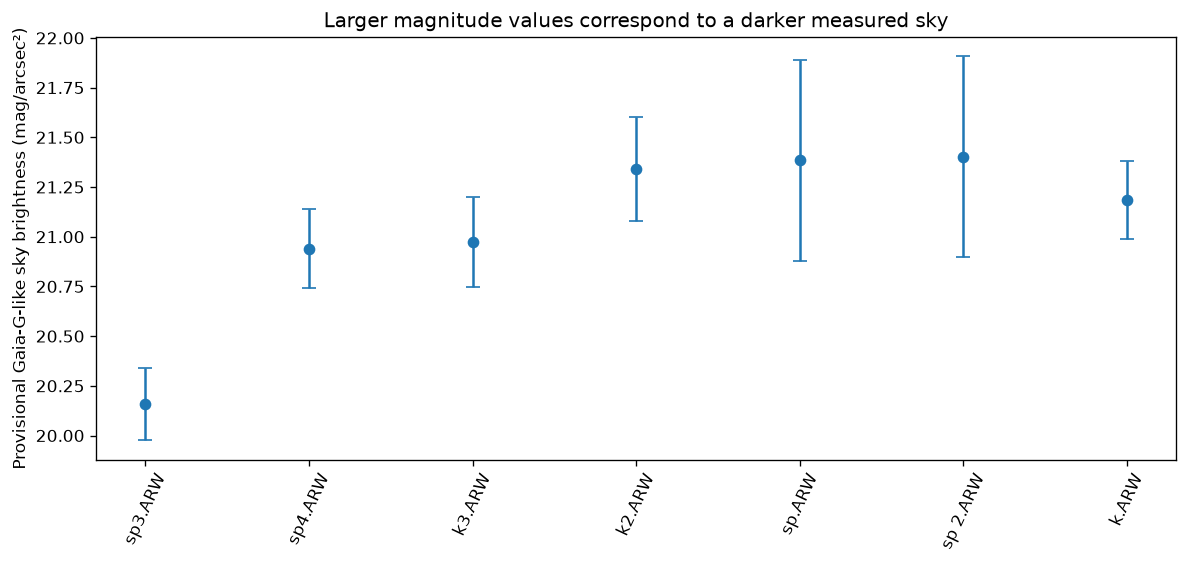

In [29]:
plot_data = surface_brightness.sort_values('captured')
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.errorbar(plot_data['file'], plot_data['estimated_gaia_g_mag_arcsec2'],
            yerr=plot_data['zero_point_scatter_mag'], fmt='o', capsize=4)
ax.set_ylabel('Provisional Gaia-G-like sky brightness (mag/arcsec²)')
ax.set_title('Larger magnitude values correspond to a darker measured sky')
ax.tick_params(axis='x', rotation=65)
fig.tight_layout()

## 9. Interpretation and next measurements

### Current result

The filename prefixes and supplied coordinates now connect every retained frame to K or SP. Plate solving provides the celestial center of each photograph; combined with site coordinates and an assumed Asia/Dhaka camera timezone, the notebook now derives the center altitude and azimuth. This tells us which part of the sky each background estimate sampled and exposes low-altitude/light-dome measurements that should not be compared with high-altitude fields.

All retained frames have statistically strong, visually checked plate solutions. The distortion-aware solutions measure internal catalog agreement; because the lens models were fitted from these images, their residuals are not independent absolute-accuracy tests. The 56 mm `k.ARW` solution centers on the Andromeda field.

The fairest available cross-site diagnostic uses only the 10 s, f/1.4, ISO 3200, 16 mm frames (`k2.ARW`, `sp.ARW`, and `sp 2.ARW`). The generated `site_summary` and printed magnitude difference quantify that subset. It is still not a controlled site comparison because the pointings differ and systematic effects from sky structure, transparency, vignetting, dark signal, atmospheric extinction, and DSLR color response are not fully propagated. A small numerical difference must not be interpreted as a site ranking.

Using the EXIF times as Bangladesh local time, the Moon was below the horizon and only about 13% illuminated in the matched comparison. However, all three matched-setting fields are on or very near the Galactic plane (`|b| < 6°`), so resolved and unresolved Milky Way light contaminates the background comparison. Under that same clock assumption, `sp.ARW` is centered at about 30° altitude and `k3.ARW` falls in astronomical twilight. These time-derived statements are conditional: the field observation that Andromeda in `k.ARW` was near culmination conflicts with its EXIF time.

At K, the plate-solved Andromeda center can reach about 70.3° altitude (19.7° from the geometric zenith) and was predicted to culminate near 01:05 Bangladesh time. `k.ARW` records 21:24, implying an offset of roughly +3 h 41 min if the exposure was actually made at culmination. The notebook reports this consistency check but does not silently alter the timestamps. Until the camera-clock offset is confirmed, altitude, azimuth, twilight, and Sun/Moon conclusions must be labeled provisional. The Galactic-latitude warning is independent of time and remains valid.

The two matching SP exposures provide a 75-second repeatability check. The former middle frame is absent from the renamed folder, so the notebook intentionally calibrates only the two retained SP frames together. All Gaia-G-like surface-brightness values remain provisional and are not Bortle assignments or substitutes for repeated SQM measurements.

What this notebook can support now:

- a reproducible inventory of the seven retained RAW files and their supplied site coordinates;
- identification of matched-setting sequences;
- checks for clipping, gradients, clouds, foreground contamination, and broadly different RAW levels;
- selection of promising frames and clean regions for deeper analysis.

What to do next for a defensible site comparison:

1. Confirm the camera clock offset. The Andromeda observation suggests about +3 h 41 min relative to EXIF, and K/SP timestamps also interleave despite the pins being about 2.6 km apart.
2. Record local weather, haze, cloud, and transparency notes for each exposure; Sun/Moon geometry is now calculated automatically.
3. Photograph the same high-altitude, low-Galactic-background field from both sites with identical settings and several repeats, ideally on the same moonless night.
4. Replace broad image polygons with matched celestial-coordinate regions that avoid the Galactic plane, M31, clouds, and obvious light domes—or model those components explicitly.
5. Capture dark frames and flat fields, then characterize camera linearity and ISO behavior.
6. Propagate zero-point, flat-field, solid-angle, extinction, and background-selection uncertainty; use repeated calibrated SQM measurements as an independent field reference.

Until those steps are complete, describe results as **relative RAW-background diagnostics from selected photographs**, not a formal determination of observatory quality.